In [ ]:
# This repository uses publicly available data derived from the Swedish Adoption/Twin Study 
#   of Aging (SATSA), provided by the Inter-university Consortium for Political and 
#   Social Research (ICPSR). 
# 
# The data are licensed for secondary use and analysis. 
# Accessed via [ICPSR #4538](https://doi.org/10.3886/ICPSR03843.v2).
#
# Citation:
#   Pedersen, Nancy L. Swedish Adoption/Twin Study on Aging (SATSA), 1984, 1987, 1990, 1993, 2004, 2007, and 2010. 
#   Inter-university Consortium for Political and Social Research [distributor], 2015-05-13.


In [ ]:
#Example of Raw psychometric data from SATSA survey:
#
# Trait Proxy: A1: I want to be the best in everything
# Year: 1984
# 1 exactly right 78 
# 2 almost right 190 
# 3 neither right nor wrong 318 
# 4 not quite right 501 
# 5 not right at all 836
#
# Normalization is not done initially so as to avoid unnecessary dimensional reduction
#   ahead of the entropy conversion.

In [ ]:
# Overview for the Notebook:
# Entropy is extracted from the SATSA dataset, then fed into a series of
# recursively interacting ODEs which were designed with ecosystem 
# constraints in mind. The driven entropy signal is compartively
# forward-simulated against the empirical entropy signal.

In [ ]:
#Unhash to reproduce environment.
#
#import sys, numpy as np, scipy
#print("Python", sys.version.split()[0],
#      "| NumPy", np.__version__,
#      "| SciPy", scipy.__version__)
#np.set_printoptions(suppress=True, precision=6)


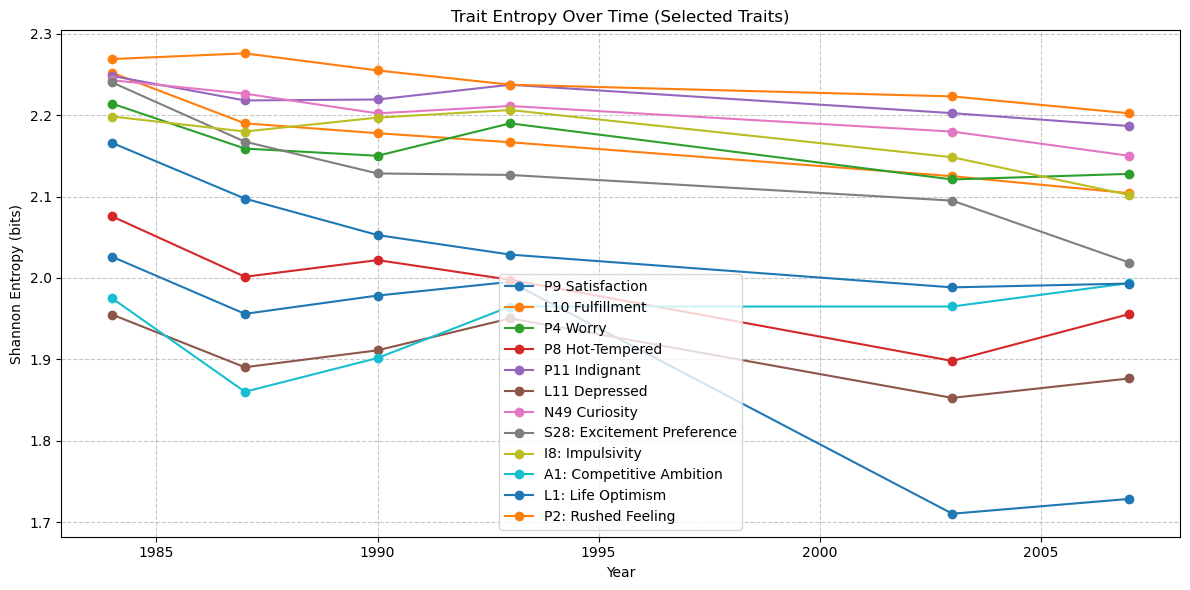

Trait                     Year    Entropy
P9 Satisfaction           1984     2.0260
P9 Satisfaction           1987     1.9559
P9 Satisfaction           1990     1.9783
P9 Satisfaction           1993     1.9952
P9 Satisfaction           2003     1.7102
P9 Satisfaction           2007     1.7284
L10 Fulfillment           1984     2.2521
L10 Fulfillment           1987     2.1900
L10 Fulfillment           1990     2.1779
L10 Fulfillment           1993     2.1668
L10 Fulfillment           2003     2.1250
L10 Fulfillment           2007     2.1041
P4 Worry                  1984     2.2142
P4 Worry                  1987     2.1590
P4 Worry                  1990     2.1501
P4 Worry                  1993     2.1900
P4 Worry                  2003     2.1210
P4 Worry                  2007     2.1279
P8 Hot-Tempered           1984     2.0755
P8 Hot-Tempered           1987     2.0014
P8 Hot-Tempered           1990     2.0219
P8 Hot-Tempered           1993     1.9978
P8 Hot-Tempered           2003    

In [2]:
# MODULE A_0: A script to extract entropy from raw SATSA data
#
# (Comparable with MODULE B_0 through B_2 of script ALife_ECTO_B_walkthrough_DENTAL.ipynb)
#
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Define Likert-scale trait frequency data
# Each list contains 5 Likert bin counts per year, from 1 (highest agreement) to 5 (lowest agreement)
# So, 1: exactly Right; 2. almost right; 3. neither right nor wrong; 4. not quite right; 5. not right at all
# The years are: 1984, 1987, 1990, 1993, 2003, 2007:
#
# Note: 
# These 12 trait matrices contain raw scores from arbitrarily selected traits assessed
# in the SATSA dataset.
#
# For the rest of the walkthrough we will select 2 traits which can be considered as 
# related, an 'N' trait, and a selected 'P' [pleiotropic] trait. 
#
# This is selecting of 'related' biologically inspired, but isn't a biochemical relation
#   in this iteration of the work.

trait_data = {
    "P9 Satisfaction": [
        [76, 231, 294, 611, 698], #Row 1984: Likert scores 1 → 5
        [48, 146, 248, 523, 593], #Row 1987: Same structure throughout
        [40, 125, 288, 480, 489], #Row 1990
        [29, 158, 289, 447, 480], #Row 1993
        [92, 443, 156, 68, 15],   #Row 2003
        [85, 354, 138, 40, 17]    #Row 2007
    ],
    "L10 Fulfillment": [
        [193, 348, 445, 539, 382],
        [114, 252, 448, 447, 291],
        [106, 230, 423, 424, 240],
        [92, 212, 461, 344, 290],
        [40, 110, 239, 235, 149],
        [25, 95, 197, 189, 126]
    ],
    "P4 Worry": [
        [159, 374, 325, 548, 527],
        [95, 241, 300, 476, 448],
        [74, 229, 309, 455, 359],
        [85, 250, 316, 391, 364],
        [29, 133, 175, 250, 185],
        [22, 113, 171, 179, 144]
    ],
    "P8 Hot-Tempered": [
        [124, 249, 287, 473, 780],
        [73, 162, 280, 360, 683],
        [60, 156, 254, 376, 576],
        [43, 179, 243, 350, 586],
        [12, 75, 137, 214, 335],
        [17, 59, 119, 178, 259]
    ],
    "P11 Indignant": [
        [185, 457, 334, 524, 415],
        [114, 332, 312, 448, 345],
        [101, 337, 329, 381, 280],
        [112, 353, 305, 344, 289],
        [53, 163, 204, 217, 139],
        [38, 139, 166, 176, 109]
    ],
    "L11 Depressed": [
        [103, 159, 269, 527, 855],
        [54, 105, 251, 450, 700],
        [38, 98, 263, 464, 563],
        [40, 114, 265, 453, 535],
        [13, 52, 135, 253, 323],
        [9, 43, 127, 200, 246]
    ],
    "N49 Curiosity": [
        [229, 520, 295, 310, 218],
        [116, 371, 402, 346, 287],
        [97, 343, 401, 319, 237],
        [99, 327, 385, 334, 245],
        [44, 196, 207, 189, 125],
        [31, 164, 193, 136, 103]
    ],
    "S28: Excitement Preference": [
        [168, 408, 514, 468, 348],
        [107, 365, 502, 360, 211],
        [94, 343, 505, 309, 168],
        [91, 341, 505, 285, 174],
        [38, 180, 287, 166, 101],
        [28, 140, 266, 128, 67]
    ],
    "I8: Impulsivity": [
        [189, 332, 263, 584, 556],
        [108, 241, 313, 457, 450],
        [110, 228, 294, 452, 343],
        [113, 236, 284, 437, 351],
        [46, 117, 181, 266, 165],
        [27, 84, 154, 214, 154]
    ],
    "A1: Competitive Ambition": [
        [78, 190, 318, 501, 836],
        [38, 98, 279, 455, 700],
        [34, 97, 292, 402, 600],
        [36, 131, 302, 368, 570],
        [16, 72, 184, 207, 297],
        [11, 67, 171, 170, 213]
    ],
    "L1: Life Optimism": [
        [278, 656, 515, 322, 156],
        [154, 444, 589, 238, 137],
        [117, 393, 569, 231, 112],
        [97, 363, 578, 264, 104],
        [36, 219, 316, 138, 63],
        [31, 156, 270, 121, 53]
    ],
    "P2: Rushed Feeling": [
        [337, 573, 274, 429, 312],
        [207, 435, 293, 368, 269],
        [149, 369, 310, 365, 237],
        [133, 411, 299, 327, 238],
        [54, 183, 185, 190, 162],
        [44, 146, 135, 191, 116]
    ],
}

years = [1984, 1987, 1990, 1993, 2003, 2007]

# Entropy extraction function:
def compute_entropy_per_year(freqs):
    entropies = []
    for year_data in freqs:
        dist = np.array(year_data, dtype=np.float64)
        dist /= dist.sum()  # Normalize
        entropies.append(entropy(dist, base=2))  # Shannon entropy, base 2
    return entropies

# Optional: visualize a few traits or all traits
if __name__ == "__main__":
    plt.figure(figsize=(12, 6))

    for trait in trait_data: #this will plot all traits
        e_vals = compute_entropy_per_year(trait_data[trait])
        plt.plot(years, e_vals, marker='o', label=trait)



    
    plt.title("Trait Entropy Over Time (Selected Traits)")
    plt.xlabel("Year")
    plt.ylabel("Shannon Entropy (bits)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Compute entropy per year per trait 
print(f"{'Trait':<25} {'Year':<6} {'Entropy':>8}")
print("=" * 42)

for trait, data in trait_data.items():
    for i, year_data in enumerate(data):
        probs = np.array(year_data) / np.sum(year_data)
        ent = entropy(probs, base=2)  # use base 2 for bits
        print(f"{trait:<25} {years[i]:<6} {ent:>8.4f}")

In [ ]:
# This next notebook uses a American dental student longitudinal survey as a demonstration 
# dataset for backup validation of the ECTO pipeline, complementing the 
# flagship SATSA runs on which the ECTO system was first tested.

# Data originally from: 'Change is never easy: Exploring the 
# transition from undergraduate to dental student in a U.S.-based program' 
# by Leite TC, Wankiiri-Hale CR, Shah NH,
# Vasquez CS, Pavlowski EM, Koury SE, et al.
# (2025) Change is never easy: Exploring the
# transition from undergraduate to dental student
# in a U.S.-based program. PLoS ONE 20(4):
# e0321494. https://doi.org/10.1371/journal.pone.0321494

# Of the original study variables, two were selected and isolated
# into a new .xlsx file :

# Variable "supp": How do you expect the academic support system to 
# be in dental school compared to undergraduate?/How would you rate 
# the academic support system in dental school compared to undergraduate?

# Variable "time": How do you expect your time management ability to 
# be in dental school compared to undergraduate?/How would you rate your
# ability to manage your time in dental school compared to undergraduate?

# Likert-style scale answers:
# Much worse=0; Worse=1; About the same=2; Better=3; Much better=4

In [5]:
### MODULE B_0: Full standalone script that takes the original dataset (pone.0321494.s005.xlsx), 
# extracts only the "supp" and "time" variables for waves D1–D4, &
# saves them as supp_time.csv 

# Note: the output file of this script is the input file for MODULE B_1

import pandas as pd

from pathlib import Path

# --- minimal repo-safe paths ---
REPO_DIR = Path.cwd()
DATA_DIR = REPO_DIR / "data"
DATA_DIR.mkdir(exist_ok=True)

orig_file = DATA_DIR / "pone.0321494.s005.xlsx"
out_csv   = DATA_DIR / "supp_time.csv"

# --- optional auto-download (works only if internet available) ---
if not orig_file.exists():
    try:
        import requests
        url = "https://doi.org/10.1371/journal.pone.0321494.s005"
        print(f"Downloading dental dataset from: {url}")
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        orig_file.write_bytes(r.content)
        print(f"Saved: {orig_file}")
    except Exception as e:
        raise FileNotFoundError(
            f"Missing file: {orig_file}\n"
            "Fix: download the PLOS ONE supplemental file (.s005) and place it at:\n"
            f"  {orig_file}\n"
            f"Download source: https://doi.org/10.1371/journal.pone.0321494.s005\n"
            f"Underlying error: {e}"
        )


def compute_likert_counts(df, prefix):
    result = {}
    for wave in ["D1", "D2", "D3", "D4"]:
        col = f"{prefix}{wave}"
        counts = df[col].value_counts(dropna=False).sort_index().to_dict()
        # Ensure r0..r4 keys exist in order
        entry = {f"r{i}": int(counts.get(i, 0)) for i in range(5)}
        entry["total"] = int(df[col].notna().sum())
        result[wave] = entry
    return result

def main():
    # Step 1. Load the original Excel file (longitudinal sheet)
    #orig_file = "/pone.0321494.s005.xlsx"   # path to original file
    df_long = pd.read_excel(orig_file, sheet_name="Longitudinal")

    # Step 2. Extract only supp and time columns (D1–D4 each)
    supp_cols = [f"suppD{i}" for i in range(1,5)]
    time_cols = [f"timeD{i}" for i in range(1,5)]
    df_supp_time = df_long[supp_cols + time_cols].copy()

    # Step 3. Save to CSV
    df_supp_time.to_csv(out_csv, index=False)

    # Step 4. Compute Likert distributions
    likert_data = {
        "supp": compute_likert_counts(df_supp_time, "supp"),
        "time": compute_likert_counts(df_supp_time, "time"),
    }

    # Step 5. Print in the requested format [NOTE: vestigial code; see MODULE B_1]
#    for var, waves in likert_data.items():
#        print(f'"{var}": {{')
#        for wave, counts in waves.items():
#            counts_str = ", ".join([f'"{k}": {v}' for k, v in counts.items()])
#            print(f'    "{wave}": {{{counts_str}}},')
#        print("},")

if __name__ == "__main__":
    main()


In [8]:
### MODULE B_1: Turn the Longitudinal data from dental students into
# ECTO-ODE-ready entropy, assessed over 4 waves [D1 through D4]

# Variable "supp": How do you expect the academic support system to 
# be in dental school compared to undergraduate?/How would you rate 
# the academic support system in dental school compared to undergraduate?

# Variable "time": How do you expect your time management ability to 
# be in dental school compared to undergraduate?/How would you rate your
# ability to manage your time in dental school compared to undergraduate?

# Likert-style scale answers:
# Much worse=0; Worse=1; About the same=2; Better=3; Much better=4

import pandas as pd
from pathlib import Path

REPO_DIR = Path.cwd()
DATA_DIR = REPO_DIR / "data"
file_path = DATA_DIR / "supp_time.csv"


def compute_likert_counts(df, prefix):
    result = {}
    for wave in ["D1", "D2", "D3", "D4"]:
        col = f"{prefix}{wave}"
        counts = df[col].value_counts(dropna=False).sort_index().to_dict()
        entry = {f"r{i}": int(counts.get(i, 0)) for i in range(5)}
        entry["total"] = int(df[col].notna().sum())
        result[wave] = entry
    return result

# Load CSV 
df = pd.read_csv(file_path)

likert_data = {
    "supp": compute_likert_counts(df, "supp"),
    "time": compute_likert_counts(df, "time"),
}

# Output from this script is in same format as the input for 'Module 2' 
for var, waves in likert_data.items():
    print(f'"{var}": {{')
    for wave, counts in waves.items():
        counts_str = ", ".join([f'"{k}": {v}' for k, v in counts.items()])
        print(f'    "{wave}": {{{counts_str}}},')
    print("},")


"supp": {
    "D1": {"r0": 0, "r1": 3, "r2": 7, "r3": 19, "r4": 17, "total": 46},
    "D2": {"r0": 0, "r1": 2, "r2": 14, "r3": 19, "r4": 9, "total": 44},
    "D3": {"r0": 1, "r1": 3, "r2": 23, "r3": 13, "r4": 6, "total": 46},
    "D4": {"r0": 1, "r1": 3, "r2": 20, "r3": 16, "r4": 6, "total": 46},
},
"time": {
    "D1": {"r0": 0, "r1": 0, "r2": 7, "r3": 22, "r4": 17, "total": 46},
    "D2": {"r0": 1, "r1": 0, "r2": 16, "r3": 16, "r4": 11, "total": 44},
    "D3": {"r0": 0, "r1": 5, "r2": 16, "r3": 18, "r4": 7, "total": 46},
    "D4": {"r0": 1, "r1": 3, "r2": 11, "r3": 25, "r4": 6, "total": 46},
},


Item     Wave    r0   r1   r2   r3   r4   sum total   Entropy(bits)
--------------------------------------------------------------------------------
supp     D1       0    3    7   19   17    46    46          1.7278
supp     D2       0    2   14   19    9    44    44          1.7198
supp     D3       1    3   23   13    6    46    46          1.7755
supp     D4       1    3   20   16    6    46    46          1.8126
time     D1       0    0    7   22   17    46    46          1.4530
time     D2       1    0   16   16   11    44    44          1.6855
time     D3       0    5   16   18    7    46    46          1.8210
time     D4       1    3   11   25    6    46    46          1.7319


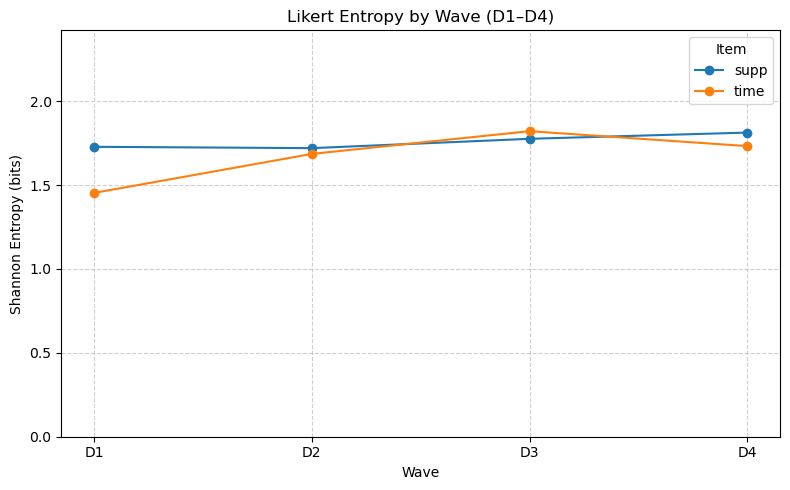

In [8]:
### MODULE B_2: Extract Entropy from Likert-style data (waves D1–D4)

# This is the first 'proper' step of the ECTO system in regards to 
# the dental student data--extracting entropy 
# from a longitudinal data source. 

# This module will yield a clean display of wave counts, as well as 
# Shannon entropy per trait per wave in bits.

# Visual plotting is offered as additional validation.

# Note: this script includes the input data generated by the author, 
# but MODULE B_0 and MODULE B_1 walk the user through 
# the process of generating this data from the original dataset 
# for purposes of scientific reproducibility.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Input data (from MODULE B_1)
# Columns: r0..r4 are the 5 Likert bins (keep their order as provided).
# 'total' is reported count (script validates vs sum of r0..r4):
likert_data = {
    "supp": {
        "D1": {"r0": 0, "r1": 3, "r2": 7, "r3": 19, "r4": 17, "total": 46},
        "D2": {"r0": 0, "r1": 2, "r2": 14, "r3": 19, "r4": 9,  "total": 44},
        "D3": {"r0": 1, "r1": 3, "r2": 23, "r3": 13, "r4": 6,  "total": 46},
        "D4": {"r0": 1, "r1": 3, "r2": 20, "r3": 16, "r4": 6,  "total": 46},
    },
    "time": {
        "D1": {"r0": 0, "r1": 0, "r2": 7,  "r3": 22, "r4": 17, "total": 46},
        "D2": {"r0": 1, "r1": 0, "r2": 16, "r3": 16, "r4": 11, "total": 44},
        "D3": {"r0": 0, "r1": 5, "r2": 16, "r3": 18, "r4": 7,  "total": 46},
        "D4": {"r0": 1, "r1": 3, "r2": 11, "r3": 25, "r4": 6,  "total": 46},
    }
}

# Fixed wave order for plotting/printing
waves = ["D1", "D2", "D3", "D4"]

# Helper

def row_to_probs(row):
    """Return probability vector (len=5) from r0..r4, handling zeros safely."""
    bins = np.array([row["r0"], row["r1"], row["r2"], row["r3"], row["r4"]], dtype=np.float64)
    s = bins.sum()
    if s == 0:
        # Degenerate case: all zero — return uniform (entropy=log2(5))
        return np.ones_like(bins) / len(bins), True
    return bins / s, False

def compute_entropy_bits(row):
    """Shannon entropy (base 2) for r0..r4 in 'row'."""
    p, was_uniform = row_to_probs(row)
    return float(entropy(p, base=2)), was_uniform

def validate_row(row):
    """Check that reported 'total' matches the sum of r0..r4."""
    s = int(row["r0"] + row["r1"] + row["r2"] + row["r3"] + row["r4"])
    return s, (s == int(row["total"]))

# Print table

print(f"{'Item':<8} {'Wave':<4}  {'r0':>4} {'r1':>4} {'r2':>4} {'r3':>4} {'r4':>4}  {'sum':>4} {'total':>5}  {'Entropy(bits)':>14}")
print("-" * 80)
for item, series in likert_data.items():
    for w in waves:
        row = series[w]
        s, ok = validate_row(row)
        H, uniform_fallback = compute_entropy_bits(row)
        flag = "" if ok else " *"  # mark rows where sum != total
        uf   = " (uniform)" if uniform_fallback else ""
        print(f"{item:<8} {w:<4}  {row['r0']:>4} {row['r1']:>4} {row['r2']:>4} {row['r3']:>4} {row['r4']:>4}  {s:>4} {row['total']:>5}{flag}  {H:>14.4f}{uf}")

if __name__ == "__main__":
    # ---------------------
    # Plot entropy per wave
    # ---------------------
    plt.figure(figsize=(8, 5))
    for item, series in likert_data.items():
        entropies = []
        for w in waves:
            H, _ = compute_entropy_bits(series[w])
            entropies.append(H)
        plt.plot(waves, entropies, marker="o", label=item)

    plt.title("Likert Entropy by Wave (D1–D4)")
    plt.xlabel("Wave")
    plt.ylabel("Shannon Entropy (bits)")
    plt.ylim(0, np.log2(5) + 0.1)  # theoretical max for 5 bins
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(title="Item")
    plt.tight_layout()
    plt.show()


In [ ]:
## We return to 'TRACK A', SATSA Analysis:


Manual Parameters:
mu = 0.00001, alpha =  0.00800, beta = 0.16031, gamma = 0.03000, c1 = 2.00000, c2 = 0.21000, c3 = 0.00000, K = 0.50000

Validation Metrics:
RMSE for P8 Hot-Tempered: 0.4064
RMSE for P4 Worry: 0.2198
R² for P8 Hot-Tempered: -0.7206
R² for P4 Worry: 0.6118
Pearson r (N): 0.885 (p=0.019)
Pearson r (P): 0.805 (p=0.053)

DTW distance (N): 1.854
DTW distance (P): 0.712


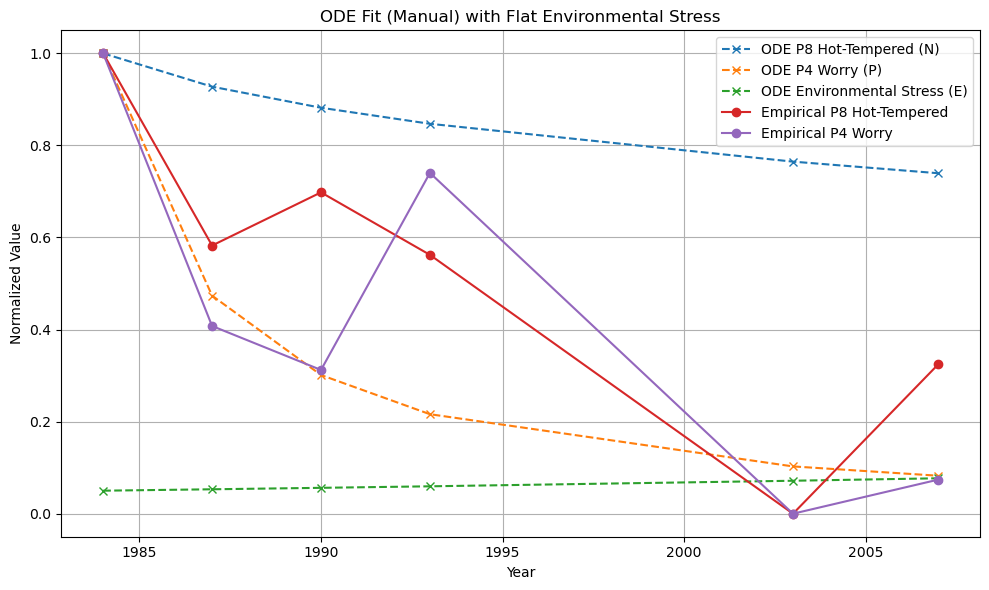

In [10]:
# MODULE A_1
#
# (Comparable with MODULE B_3 of script ALife_ECTO_B_walkthrough_DENTAL.ipynb)
#
# ECTO Nonlinear ODE System
#
# 'FIRST parameter Set', Manual parameter settings for illustrative purposes
#
# Note: This module is able to run via L-BFGS-B Optimization, 
# or with Manual Parameter fitting (Manual default shown)
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# Toggle: Use Optimizer or Manually Set Parameters (Default = False)
use_optimizer = False  # <<< Set to False to manually adjust parameters

# Trait Entropy Data (Import Likert-cum-entropy Data),
# We will select two of the following: 
data = {
    "Year": [1984, 1987, 1990, 1993, 2003, 2007],
    "P9 Satisfaction": [2.0260, 1.9559, 1.9783, 1.9952, 1.7102, 1.7284],
    "L10 Fulfillment": [2.2521, 2.1900, 2.1779, 2.1668, 2.1250, 2.1041],
    "P4 Worry": [2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279],
    "P8 Hot-Tempered": [2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556],
    "P11 Indignant": [2.2481, 2.2181, 2.2193, 2.2374, 2.2025, 2.1867],
    "L11 Depressed": [1.9549, 1.8902, 1.9110, 1.9503, 1.8526, 1.8764],
    "N49 Curiosity": [2.2429, 2.2265, 2.2022, 2.2113, 2.1799, 2.1501],
    "S28 Excitement Preference": [2.2402, 2.1675, 2.1284, 2.1266, 2.0950, 2.0190],
    "I8 Impulsivity": [2.1984, 2.1799, 2.1970, 2.2063, 2.1483, 2.1020],
    "A1 Competitive Ambition": [1.9748, 1.8601, 1.9016, 1.9649, 1.9649, 1.9936],
    "L1 Life Optimism": [2.1659, 2.0975, 2.0527, 2.0287, 1.9884, 1.9931],
    "P2 Rushed Feeling": [2.2690, 2.2760, 2.2550, 2.2375, 2.2231, 2.2023]
}
df = pd.DataFrame(data)

# Two selected traits
trait_x = "P8 Hot-Tempered"
trait_y = "P4 Worry"

years = np.array(df["Year"])
t_data = years - years[0]

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

N_empirical = normalize(df[trait_x].values)
P_empirical = normalize(df[trait_y].values)

# ODE System without Oscillating E (E can be flattened or perturbed as appropriate):
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K):
    N, P, E = y
    omega = 0.8  #Not utilized when E left flat
    amplitude = 0.05 #Not utilized when E left flat
    E_dynamic = c1 * P + c2 * N + c3 * E
    dNdt = mu * N - alpha * N**2 - beta**2 * N * P
    dPdt = mu * P - beta * P * E_dynamic
    dEdt = gamma * E * (N / (N + K)) 
    return [dNdt, dPdt, dEdt]

# Initial Conditions:
init_conditions = [N_empirical[0], P_empirical[0], 0.05]

# Objective Function:
def objective(params):
    mu, alpha, beta, gamma, c1, c2, c3, K = params
    sol = odeint(system, init_conditions, t_data, args=(mu, beta, gamma, c1, c2, c3, K))
    error_N = np.sum((sol[:, 0] - N_empirical)**2)
    error_P = np.sum((sol[:, 1] - P_empirical)**2)
    return error_N + error_P

# Choose Parameters:
if use_optimizer:
    initial_guess = [0.0002, 0.1, 0.2, 0.03, 1.0, 0.45, 0.3, 0.5]
    bounds = [
        (1e-5, 0.01), (0.001, 0.8), (0.01, 0.5), (0.01, 0.5),
        (0.21, 2.0), (0.21, 2.0), (0.01, 2.0), (0.21, 2.0)
    ]
    result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')
    mu, alpha, beta, gamma, c1, c2, c3, K = result.x
else:
    # MANUAL PARAMETER EXPLORATION (this will engage when 'Use Optimizer' is set to 'FALSE'): 
    mu    = 0.00001
    alpha = 0.008
    beta  = 0.16031
    gamma = 0.03
    c1    = 2.0
    c2    = 0.21
    c3    = 0.0   # <- Try changing this to see effect of E_stress feedback!
    K     = 0.5

# Simulate System:
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
N_model, P_model, E_model = sol.T

# Validation:
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)

# Shape Metrics:
# DTW function:
def dtw_distance(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

rN, pN = pearsonr(N_empirical, N_model)
rP, pP = pearsonr(P_empirical, P_model)
dtwN = dtw_distance(N_empirical, N_model)
dtwP = dtw_distance(P_empirical, P_model)

# === Output ===
print(f"\n{'Optimized' if use_optimizer else 'Manual'} Parameters:")
print(f"mu = {mu:.5f}, alpha = {alpha: .5f}, beta = {beta:.5f}, gamma = {gamma:.5f}, c1 = {c1:.5f}, c2 = {c2:.5f}, c3 = {c3:.5f}, K = {K:.5f}")
print(f"\nValidation Metrics:")
print(f"RMSE for {trait_x}: {rmse_N:.4f}")
print(f"RMSE for {trait_y}: {rmse_P:.4f}")
print(f"R² for {trait_x}: {r2_N:.4f}")
print(f"R² for {trait_y}: {r2_P:.4f}")
print(f"Pearson r (N): {rN:.3f} (p={pN:.3f})")
print(f"Pearson r (P): {rP:.3f} (p={pP:.3f})\n")
print(f"DTW distance (N): {dtwN:.3f}")
print(f"DTW distance (P): {dtwP:.3f}")

# === Plot ===
plt.figure(figsize=(10, 6))
plt.plot(years, N_model, 'x--', label=f'ODE {trait_x} (N)')
plt.plot(years, P_model, 'x--', label=f'ODE {trait_y} (P)')
plt.plot(years, E_model, 'x--', label='ODE Environmental Stress (E)')
plt.plot(years, N_empirical, 'o-', label=f'Empirical {trait_x}')
plt.plot(years, P_empirical, 'o-', label=f'Empirical {trait_y}')
plt.title(f"ODE Fit ({'Optimized' if use_optimizer else 'Manual'}) with Flat Environmental Stress")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Manual Parameters:
mu = 0.00001, alpha =  0.05300, beta = 0.16746, gamma = 0.03000, c1 = 2.00000, c2 = 0.21000, c3 = 0.00000, K = 0.50000

Validation Metrics:
RMSE for P8 Hot-Tempered: 0.2117
RMSE for P4 Worry: 0.2205
R² for P8 Hot-Tempered: 0.5330
R² for P4 Worry: 0.6093
Pearson r (N): 0.886 (p=0.019)
Pearson r (P): 0.803 (p=0.054)

DTW distance (N): 0.834
DTW distance (P): 0.722


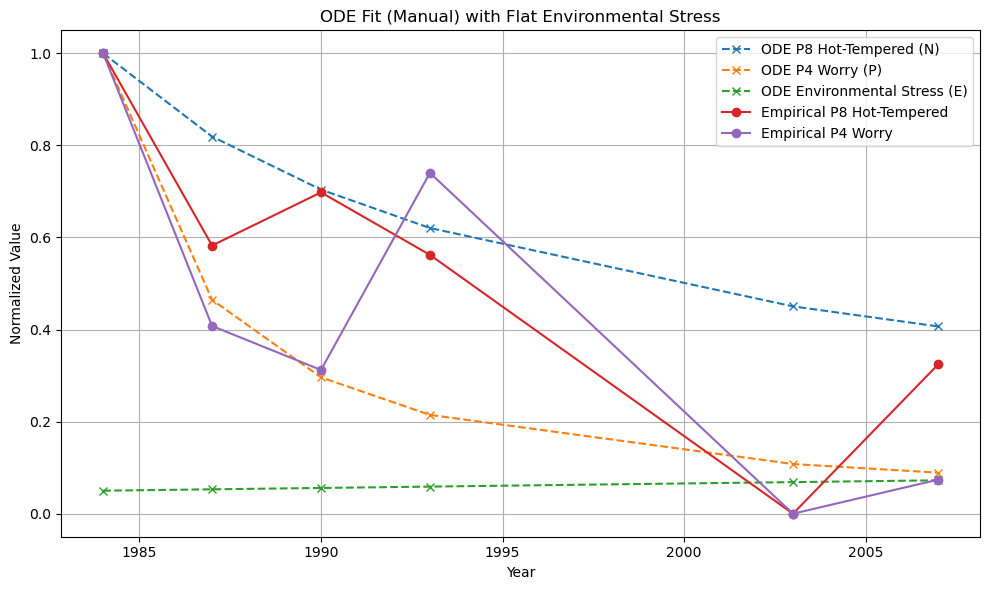

In [12]:
# MODULE A_2
#
# (Comparable with MODULE B_3 of script ALife_ECTO_B_walkthrough_DENTAL.ipynb)
#
# 'SECOND parameter Set': Manual parameter settings for illustrative purposes
#
# Note: This module is able to run via L-BFGS-B Optimization, 
# or with Manual Parameter fitting (Manual default shown)
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# Toggle: Use Optimizer or Manually Set Parameters
use_optimizer = False  # <<< Set to False to manually adjust c3 and others

# Trait Entropy Data (Import Likert-cum-entropy Data): 
data = {
    "Year": [1984, 1987, 1990, 1993, 2003, 2007],
    "P9 Satisfaction": [2.0260, 1.9559, 1.9783, 1.9952, 1.7102, 1.7284],
    "L10 Fulfillment": [2.2521, 2.1900, 2.1779, 2.1668, 2.1250, 2.1041],
    "P4 Worry": [2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279],
    "P8 Hot-Tempered": [2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556],
    "P11 Indignant": [2.2481, 2.2181, 2.2193, 2.2374, 2.2025, 2.1867],
    "L11 Depressed": [1.9549, 1.8902, 1.9110, 1.9503, 1.8526, 1.8764],
    "N49 Curiosity": [2.2429, 2.2265, 2.2022, 2.2113, 2.1799, 2.1501],
    "S28: Excitement Preference": [2.2402, 2.1675, 2.1284, 2.1266, 2.0950, 2.0190],
    "I8: Impulsivity": [2.1984, 2.1799, 2.1970, 2.2063, 2.1483, 2.1020],
    "A1: Competitive Ambition": [1.9748, 1.8601, 1.9016, 1.9649, 1.9649, 1.9936],
    "L1: Life Optimism": [2.1659, 2.0975, 2.0527, 2.0287, 1.9884, 1.9931],
    "P2: Rushed Feeling": [2.2690, 2.2760, 2.2550, 2.2375, 2.2231, 2.2023]
}
df = pd.DataFrame(data)

trait_x = "P8 Hot-Tempered"
trait_y = "P4 Worry"

years = np.array(df["Year"])
t_data = years - years[0]

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

N_empirical = normalize(df[trait_x].values)
P_empirical = normalize(df[trait_y].values)

# ODE System without Oscillating E (E can be flattened or perturbed as appropriate):
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K):
    N, P, E = y
    omega = 0.8
    amplitude = 0.05
    E_dynamic = c1 * P + c2 * N + c3 * E
    dNdt = mu * N - alpha * N**2 - beta**2 * N * P
    dPdt = mu * P - beta * P * E_dynamic
    dEdt = gamma * E * (N / (N + K)) 
    return [dNdt, dPdt, dEdt]

# Initial Conditions:
init_conditions = [N_empirical[0], P_empirical[0], 0.05]

# Objective Function:
def objective(params):
    mu, alpha, beta, gamma, c1, c2, c3, K = params
    sol = odeint(system, init_conditions, t_data, args=(mu, beta, gamma, c1, c2, c3, K))
    error_N = np.sum((sol[:, 0] - N_empirical)**2)
    error_P = np.sum((sol[:, 1] - P_empirical)**2)
    return error_N + error_P

# Choose Parameters:
if use_optimizer:
    initial_guess = [0.0002, 0.1, 0.2, 0.03, 1.0, 0.45, 0.3, 0.5]
    bounds = [
        (1e-5, 0.01), (0.001, 0.8), (0.01, 0.5), (0.01, 0.5),
        (0.21, 2.0), (0.21, 2.0), (0.01, 2.0), (0.21, 2.0)
    ]
    result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')
    mu, alpha, beta, gamma, c1, c2, c3, K = result.x
else:
    # MANUAL PARAMETER EXPLORATION (this will engage when 'Use Optimizer' is set to 'FALSE'): 
    mu    = 0.00001
    alpha = 0.053
    beta  = 0.16746
    gamma = 0.03
    c1    = 2.0
    c2    = 0.21
    c3    = 0.0   # << Try changing this to see effect of E_stress feedback!
    K     = 0.5

# Simulate System:
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
N_model, P_model, E_model = sol.T

# Validation:
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)

# Shape Metrics:
# DTW function:
def dtw_distance(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

rN, pN = pearsonr(N_empirical, N_model)
rP, pP = pearsonr(P_empirical, P_model)
dtwN = dtw_distance(N_empirical, N_model)
dtwP = dtw_distance(P_empirical, P_model)

# === Output ===
print(f"\n{'Optimized' if use_optimizer else 'Manual'} Parameters:")
print(f"mu = {mu:.5f}, alpha = {alpha: .5f}, beta = {beta:.5f}, gamma = {gamma:.5f}, c1 = {c1:.5f}, c2 = {c2:.5f}, c3 = {c3:.5f}, K = {K:.5f}")
print(f"\nValidation Metrics:")
print(f"RMSE for {trait_x}: {rmse_N:.4f}")
print(f"RMSE for {trait_y}: {rmse_P:.4f}")
print(f"R² for {trait_x}: {r2_N:.4f}")
print(f"R² for {trait_y}: {r2_P:.4f}")
print(f"Pearson r (N): {rN:.3f} (p={pN:.3f})")
print(f"Pearson r (P): {rP:.3f} (p={pP:.3f})\n")
print(f"DTW distance (N): {dtwN:.3f}")
print(f"DTW distance (P): {dtwP:.3f}")

# === Plot ===
plt.figure(figsize=(10, 6))
plt.plot(years, N_model, 'x--', label=f'ODE {trait_x} (N)')
plt.plot(years, P_model, 'x--', label=f'ODE {trait_y} (P)')
plt.plot(years, E_model, 'x--', label='ODE Environmental Stress (E)')
plt.plot(years, N_empirical, 'o-', label=f'Empirical {trait_x}')
plt.plot(years, P_empirical, 'o-', label=f'Empirical {trait_y}')
plt.title(f"ODE Fit ({'Optimized' if use_optimizer else 'Manual'}) with Flat Environmental Stress")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Manual Parameters:
mu = 0.00001, alpha =  0.09800, beta = 0.17117, gamma = 0.03000, c1 = 2.00000, c2 = 0.21000, c3 = 0.00000, K = 0.50000

Validation Metrics:
RMSE for P8 Hot-Tempered: 0.1552
RMSE for P4 Worry: 0.2205
R² for P8 Hot-Tempered: 0.7491
R² for P4 Worry: 0.6095
Pearson r (N): 0.879 (p=0.021)
Pearson r (P): 0.803 (p=0.055)

DTW distance (N): 0.648
DTW distance (P): 0.725


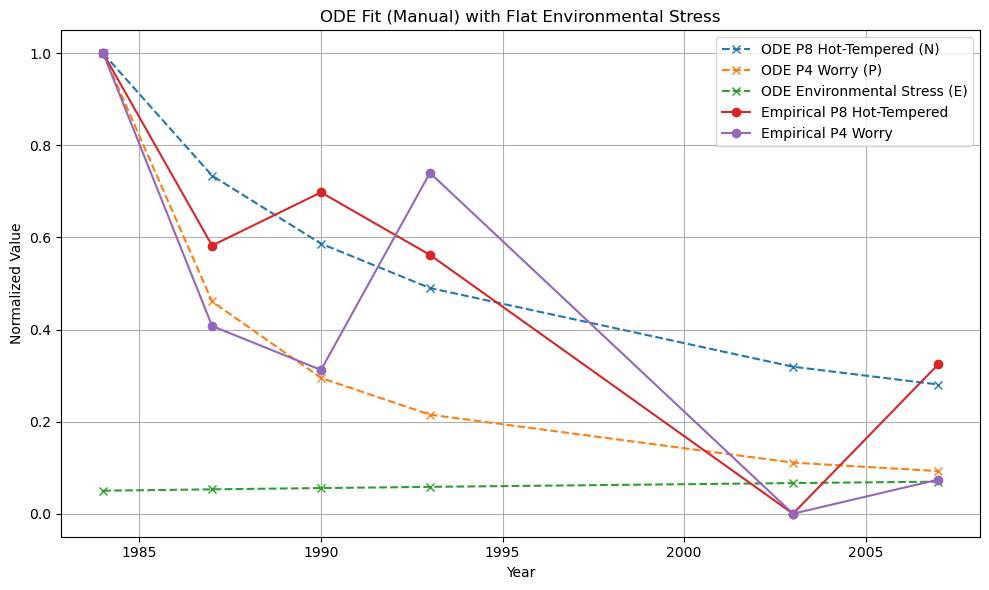

In [14]:
# MODULE A_3
#
# 'THIRD parameter Set': Manual parameter settings for illustrative purposes
#
# Note: This module is able to run via L-BFGS-B Optimization, 
# or with Manual Parameter fitting (Manual default shown)
# 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# Toggle: Use Optimizer or Manually Set Parameters
use_optimizer = False  # <<< Set to False to manually adjust c3 and others

# Trait Entropy Data (Import Likert-cum-entropy Data): 
data = {
    "Year": [1984, 1987, 1990, 1993, 2003, 2007],
    "P9 Satisfaction": [2.0260, 1.9559, 1.9783, 1.9952, 1.7102, 1.7284],
    "L10 Fulfillment": [2.2521, 2.1900, 2.1779, 2.1668, 2.1250, 2.1041],
    "P4 Worry": [2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279],
    "P8 Hot-Tempered": [2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556],
    "P11 Indignant": [2.2481, 2.2181, 2.2193, 2.2374, 2.2025, 2.1867],
    "L11 Depressed": [1.9549, 1.8902, 1.9110, 1.9503, 1.8526, 1.8764],
    "N49 Curiosity": [2.2429, 2.2265, 2.2022, 2.2113, 2.1799, 2.1501],
    "S28: Excitement Preference": [2.2402, 2.1675, 2.1284, 2.1266, 2.0950, 2.0190],
    "I8: Impulsivity": [2.1984, 2.1799, 2.1970, 2.2063, 2.1483, 2.1020],
    "A1: Competitive Ambition": [1.9748, 1.8601, 1.9016, 1.9649, 1.9649, 1.9936],
    "L1: Life Optimism": [2.1659, 2.0975, 2.0527, 2.0287, 1.9884, 1.9931],
    "P2: Rushed Feeling": [2.2690, 2.2760, 2.2550, 2.2375, 2.2231, 2.2023]
}
df = pd.DataFrame(data)

trait_x = "P8 Hot-Tempered"
trait_y = "P4 Worry"

years = np.array(df["Year"])
t_data = years - years[0]

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

N_empirical = normalize(df[trait_x].values)
P_empirical = normalize(df[trait_y].values)

# ODE System without Oscillating E (E can be flattened or perturbed as appropriate):
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K):
    N, P, E = y
    omega = 0.8 #incosequential with Flat E
    amplitude = 0.05 #inconsequential with Flat E
    E_dynamic = c1 * P + c2 * N + c3 * E
    dNdt = mu * N - alpha * N**2 - beta**2 * N * P
    dPdt = mu * P - beta * P * E_dynamic
    dEdt = gamma * E * (N / (N + K)) 
    return [dNdt, dPdt, dEdt]

# Initial Conditions:
init_conditions = [N_empirical[0], P_empirical[0], 0.05]

# Objective Function:
def objective(params):
    mu, alpha, beta, gamma, c1, c2, c3, K = params
    sol = odeint(system, init_conditions, t_data, args=(mu, beta, gamma, c1, c2, c3, K))
    error_N = np.sum((sol[:, 0] - N_empirical)**2)
    error_P = np.sum((sol[:, 1] - P_empirical)**2)
    return error_N + error_P

# Choose Parameters:
if use_optimizer:
    initial_guess = [0.0002, 0.1, 0.2, 0.03, 1.0, 0.45, 0.3, 0.5]
    bounds = [
        (1e-5, 0.01), (0.001, 0.8), (0.01, 0.5), (0.01, 0.5),
        (0.21, 2.0), (0.21, 2.0), (0.01, 2.0), (0.21, 2.0)
    ]
    result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')
    mu, alpha, beta, gamma, c1, c2, c3, K = result.x
else:
    # MANUAL PARAMETER EXPLORATION (this will engage when 'Use Optimizer' is set to 'FALSE'): 
    mu    = 0.00001
    alpha = 0.098
    beta  = 0.17117
    gamma = 0.03
    c1    = 2.0
    c2    = 0.21
    c3    = 0.0   # << Try changing this to see effect of E_stress feedback!
    K     = 0.5

# Simulate System:
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
N_model, P_model, E_model = sol.T

# Validation:
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)

# Shape Metrics:
# DTW function:
def dtw_distance(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

rN, pN = pearsonr(N_empirical, N_model)
rP, pP = pearsonr(P_empirical, P_model)
dtwN = dtw_distance(N_empirical, N_model)
dtwP = dtw_distance(P_empirical, P_model)

# === Output ===
print(f"\n{'Optimized' if use_optimizer else 'Manual'} Parameters:")
print(f"mu = {mu:.5f}, alpha = {alpha: .5f}, beta = {beta:.5f}, gamma = {gamma:.5f}, c1 = {c1:.5f}, c2 = {c2:.5f}, c3 = {c3:.5f}, K = {K:.5f}")
print(f"\nValidation Metrics:")
print(f"RMSE for {trait_x}: {rmse_N:.4f}")
print(f"RMSE for {trait_y}: {rmse_P:.4f}")
print(f"R² for {trait_x}: {r2_N:.4f}")
print(f"R² for {trait_y}: {r2_P:.4f}")
print(f"Pearson r (N): {rN:.3f} (p={pN:.3f})")
print(f"Pearson r (P): {rP:.3f} (p={pP:.3f})\n")
print(f"DTW distance (N): {dtwN:.3f}")
print(f"DTW distance (P): {dtwP:.3f}")

# === Plot ===
plt.figure(figsize=(10, 6))
plt.plot(years, N_model, 'x--', label=f'ODE {trait_x} (N)')
plt.plot(years, P_model, 'x--', label=f'ODE {trait_y} (P)')
plt.plot(years, E_model, 'x--', label='ODE Environmental Stress (E)')
plt.plot(years, N_empirical, 'o-', label=f'Empirical {trait_x}')
plt.plot(years, P_empirical, 'o-', label=f'Empirical {trait_y}')
plt.title(f"ODE Fit ({'Optimized' if use_optimizer else 'Manual'}) with Flat Environmental Stress")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Manual Parameters:
mu = 0.00001, alpha =  0.09800, beta = 0.17117, gamma = 0.03000, c1 = 2.00000, c2 = 0.21000, c3 = 12.60000, K = 0.50000

Validation Metrics:
RMSE for P8 Hot-Tempered: 0.1590
RMSE for P4 Worry: 0.2915
R² for P8 Hot-Tempered: 0.7367
R² for P4 Worry: 0.3176
Pearson r (N): 0.880 (p=0.021)
Pearson r (P): 0.777 (p=0.069)

DTW distance (N): 0.655
DTW distance (P): 0.783


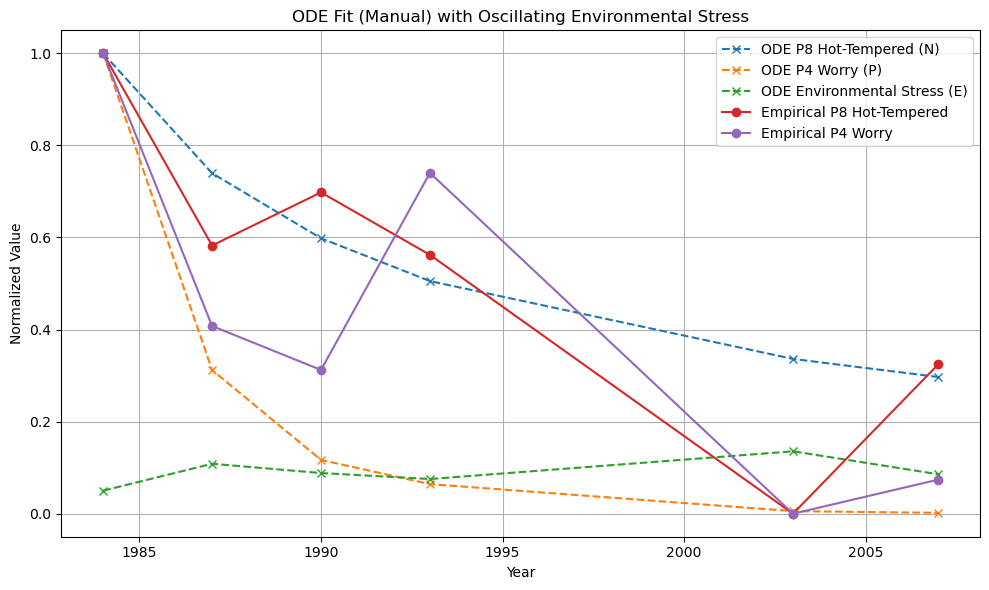

In [16]:
# MODULE A_4
#
# 'FOURTH parameter Set': Manual parameter settings for illustrative purposes
#
# Note: This module is able to run via L-BFGS-B Optimization, 
#   or with Manual Parameter fitting (Manual default shown)
#
# Additionally, a critical note, is that this is the first A_module which 
#   utilizes the E_stress parameter [manipulable as "c3"]
#
# All depicted parameterizations were selected for illustrative purposes 
#   for the A_series of modules. Optimized parameters were selected for
#   the Module B_series, which is run on a different 
#   dataset (see the 'B-Track' of this notebook)
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# Toggle: Use Optimizer or Manually Set Parameters
use_optimizer = False  # <<< Set to False to manually adjust c3 and others

# Trait Entropy Data (Import Likert-cum-entropy Data): 
data = {
    "Year": [1984, 1987, 1990, 1993, 2003, 2007],
    "P9 Satisfaction": [2.0260, 1.9559, 1.9783, 1.9952, 1.7102, 1.7284],
    "L10 Fulfillment": [2.2521, 2.1900, 2.1779, 2.1668, 2.1250, 2.1041],
    "P4 Worry": [2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279],
    "P8 Hot-Tempered": [2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556],
    "P11 Indignant": [2.2481, 2.2181, 2.2193, 2.2374, 2.2025, 2.1867],
    "L11 Depressed": [1.9549, 1.8902, 1.9110, 1.9503, 1.8526, 1.8764],
    "N49 Curiosity": [2.2429, 2.2265, 2.2022, 2.2113, 2.1799, 2.1501],
    "S28: Excitement Preference": [2.2402, 2.1675, 2.1284, 2.1266, 2.0950, 2.0190],
    "I8: Impulsivity": [2.1984, 2.1799, 2.1970, 2.2063, 2.1483, 2.1020],
    "A1: Competitive Ambition": [1.9748, 1.8601, 1.9016, 1.9649, 1.9649, 1.9936],
    "L1: Life Optimism": [2.1659, 2.0975, 2.0527, 2.0287, 1.9884, 1.9931],
    "P2: Rushed Feeling": [2.2690, 2.2760, 2.2550, 2.2375, 2.2231, 2.2023]
}
df = pd.DataFrame(data)

trait_x = "P8 Hot-Tempered"
trait_y = "P4 Worry"

years = np.array(df["Year"])
t_data = years - years[0]

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

N_empirical = normalize(df[trait_x].values)
P_empirical = normalize(df[trait_y].values)

# ODE System with Oscillating E (E can be flattened or perturbed as appropriate):
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K):
    N, P, E = y
    omega = 0.8
    amplitude = 0.05
    E_dynamic = c1 * P + c2 * N + c3 * E
    dNdt = mu * N - alpha * N**2 - beta**2 * N * P
    dPdt = mu * P - beta * P * E_dynamic
    dEdt = gamma * E * (N / (N + K)) + amplitude * 0.5 * np.sin(omega * t)
    return [dNdt, dPdt, dEdt]

# Initial Conditions:
init_conditions = [N_empirical[0], P_empirical[0], 0.05]

# Objective Function:
def objective(params):
    mu, beta, alpha, gamma, c1, c2, c3, K = params
    sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
    error_N = np.sum((sol[:, 0] - N_empirical)**2)
    error_P = np.sum((sol[:, 1] - P_empirical)**2)
    return error_N + error_P

# Choose Parameters:
if use_optimizer:
    initial_guess = [0.0002, 0.1, 0.2, 0.03, 1.0, 0.45, 0.3, 0.5]
    bounds = [
        (1e-5, 0.01), (0.001, 0.8), (0.01, 0.5), (0.01, 0.5),
        (0.21, 2.0), (0.21, 2.0), (0.01, 2.0), (0.21, 2.0)
    ]
    result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')
    mu, alpha, beta, gamma, c1, c2, c3, K = result.x
else:
    # MANUAL PARAMETER EXPLORATION (this will engage when 'Use Optimizer' is set to 'FALSE'): 
    mu    = 0.00001
    alpha = 0.098
    beta  = 0.17117
    gamma = 0.03
    c1    = 2.0
    c2    = 0.21
    c3    = 012.60   # << Try changing this to see effect of E_stress feedback!
    K     = 0.5

# Simulate System:
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
N_model, P_model, E_model = sol.T

# Validation:
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)

# Shape Metrics:
# DTW function:
def dtw_distance(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

rN, pN = pearsonr(N_empirical, N_model)
rP, pP = pearsonr(P_empirical, P_model)
dtwN = dtw_distance(N_empirical, N_model)
dtwP = dtw_distance(P_empirical, P_model)

# === Output ===
print(f"\n{'Optimized' if use_optimizer else 'Manual'} Parameters:")
print(f"mu = {mu:.5f}, alpha = {alpha: .5f}, beta = {beta:.5f}, gamma = {gamma:.5f}, c1 = {c1:.5f}, c2 = {c2:.5f}, c3 = {c3:.5f}, K = {K:.5f}")
print(f"\nValidation Metrics:")
print(f"RMSE for {trait_x}: {rmse_N:.4f}")
print(f"RMSE for {trait_y}: {rmse_P:.4f}")
print(f"R² for {trait_x}: {r2_N:.4f}")
print(f"R² for {trait_y}: {r2_P:.4f}")
print(f"Pearson r (N): {rN:.3f} (p={pN:.3f})")
print(f"Pearson r (P): {rP:.3f} (p={pP:.3f})\n")
print(f"DTW distance (N): {dtwN:.3f}")
print(f"DTW distance (P): {dtwP:.3f}")

# === Plot ===
plt.figure(figsize=(10, 6))
plt.plot(years, N_model, 'x--', label=f'ODE {trait_x} (N)')
plt.plot(years, P_model, 'x--', label=f'ODE {trait_y} (P)')
plt.plot(years, E_model, 'x--', label='ODE Environmental Stress (E)')
plt.plot(years, N_empirical, 'o-', label=f'Empirical {trait_x}')
plt.plot(years, P_empirical, 'o-', label=f'Empirical {trait_y}')
plt.title(f"ODE Fit ({'Optimized' if use_optimizer else 'Manual'}) with Oscillating Environmental Stress")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
## TRACK A, Continued Below ##

=== LOO (hold one time point; fit on the other five) ===
Hold 1984 | N_true=1.000 N_pred=1.000 | P_true=1.000 P_pred=1.000 | CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL | SSE=0.358236
Hold 1987 | N_true=0.583 N_pred=0.729 | P_true=0.408 P_pred=0.740 | CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH | SSE=0.264926
Hold 1990 | N_true=0.698 N_pred=0.463 | P_true=0.312 P_pred=0.609 | CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL | SSE=0.270166
Hold 1993 | N_true=0.562 N_pred=0.408 | P_true=0.740 P_pred=0.176 | CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH | SSE=0.126390
Hold 2003 | N_true=0.000 N_pred=0.361 | P_true=0.000 P_pred=0.198 | CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH | SSE=0.247171
Hold 2007 | N_true=0.325 N_pred=0.229 | P_true=0.074 P_pred=0.000 | CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH | SSE=0.345947

LOO RMSE — P8 Hot-Tempered: 0.2001 | P4 Worry: 0.3061

=== Full-data fit (display) ===
Optimizer: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL | SSE= 

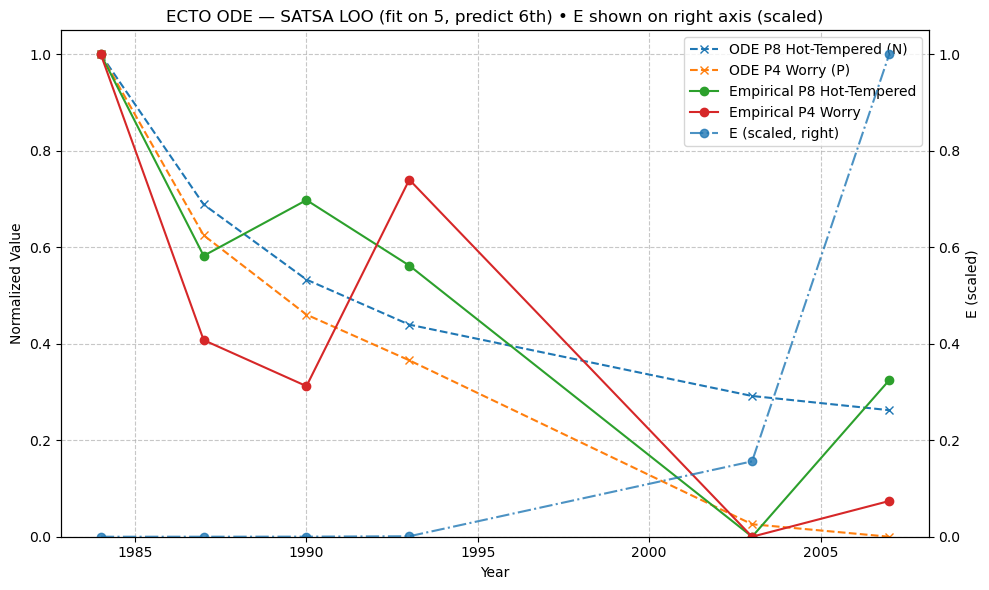

In [22]:
# MODULE A_5
# Leave-One-Out (LOO) Cross-Validation with Partial Parameter Fitting 
# Note: This cell corresponds with MODULE B_6 : Statistical Validation I
#      
# SATSA LOO (leave-one-out) with optimizer; E on right axis (scaled)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score

# ---------------- Data (SATSA table) ----------------
# Choose 2 of the following: 
data = {
    "Year": [1984, 1987, 1990, 1993, 2003, 2007],
    "P9 Satisfaction": [2.0260, 1.9559, 1.9783, 1.9952, 1.7102, 1.7284],
    "L10 Fulfillment": [2.2521, 2.1900, 2.1779, 2.1668, 2.1250, 2.1041],
    "P4 Worry": [2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279],
    "P8 Hot-Tempered": [2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556],
    "P11 Indignant": [2.2481, 2.2181, 2.2193, 2.2374, 2.2025, 2.1867],
    "L11 Depressed": [1.9549, 1.8902, 1.9110, 1.9503, 1.8526, 1.8764],
    "N49 Curiosity": [2.2429, 2.2265, 2.2022, 2.2113, 2.1799, 2.1501],
    "S28: Excitement Preference": [2.2402, 2.1675, 2.1284, 2.1266, 2.0950, 2.0190],
    "I8: Impulsivity": [2.1984, 2.1799, 2.1970, 2.2063, 2.1483, 2.1020],
    "A1: Competitive Ambition": [1.9748, 1.8601, 1.9016, 1.9649, 1.9649, 1.9936],
    "L1: Life Optimism": [2.1659, 2.0975, 2.0527, 2.0287, 1.9884, 1.9931],
    "P2: Rushed Feeling": [2.2690, 2.2760, 2.2550, 2.2375, 2.2231, 2.2023]
}
df = pd.DataFrame(data)

# Insert full label of 2 chosen traits
trait_x = "P8 Hot-Tempered"
trait_y = "P4 Worry"

years = np.array(df["Year"], dtype=float)
t_full = years - years[0]   # real year gaps (not 0..5)

def normalize(a):
    a = np.asarray(a, float); r = a.max() - a.min()
    return (a - a.min())/r if r > 0 else np.zeros_like(a)

N_emp = normalize(df[trait_x].values)
P_emp = normalize(df[trait_y].values)
waves = [f"D{i+1}" for i in range(len(years))]

# ---------------- ECTO ODE System ----------------
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K):
    N, P, E = y
    E_dynamic = c1 * P + c2 * N + c3 * E
    dNdt = mu * N - alpha * N**2 - beta**2 * N * P
    dPdt = mu * P - beta * P * E_dynamic
    dEdt = gamma * E * (N / (N + K)) if (N + K) != 0 else 0.0
    return [dNdt, dPdt, dEdt]

# ---------------- Optimizer setup ----------------
# Starting 'neighborhood' settings chosen for illustrative purposes
initial_guess = [0.0002, 0.1, 0.2, 0.03, 1.0, 0.45, 0.3, 0.5]  # [mu,alpha,beta,gamma,c1,c2,c3,K]
bounds = [
    (1e-6, 0.02),   # mu   (slow net growth fits SATSA scale)
    (0.001, 0.8),   # alpha
    (0.01, 0.5),    # beta
    (0.01, 0.8),    # gamma
    (0.2,  2.5),    # c1
    (0.2,  2.5),    # c2
    (0.0,  2.0),    # c3
    (0.2,  2.0),    # K
]

eps = 1e-8  # tiny epsilon to avoid exact 0 invariants

def objective(params, obs_idx):
    mu, alpha, beta, gamma, c1, c2, c3, K = params
    y0 = [max(N_emp[0], eps), max(P_emp[0], eps), 0.05]
    sol = odeint(system, y0, t_full, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
    N_mod, P_mod = sol[:,0], sol[:,1]
    errN = np.sum((N_mod[obs_idx] - N_emp[obs_idx])**2)
    errP = np.sum((P_mod[obs_idx] - P_emp[obs_idx])**2)
    return errN + errP

def fit_fold(obs_idx, x0=None):
    if x0 is None:
        x0 = initial_guess
    res = minimize(lambda p: objective(p, obs_idx), x0, bounds=bounds, method='L-BFGS-B')
    return res

def simulate(params):
    mu, alpha, beta, gamma, c1, c2, c3, K = params
    y0 = [max(N_emp[0], eps), max(P_emp[0], eps), 0.05]
    sol = odeint(system, y0, t_full, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
    return sol.T  # N_model, P_model, E_model


# Leave One Out (LOO) Analysis (6 folds)
all_idx = np.arange(len(years))
print("=== LOO (hold one time point; fit on the other five) ===")
held = []
for hold in all_idx:
    obs_idx = np.delete(all_idx, hold)
    res = fit_fold(obs_idx)
    params = res.x
    N_mod, P_mod, _ = simulate(params)
    out = (years[hold], float(N_emp[hold]), float(N_mod[hold]), float(P_emp[hold]), float(P_mod[hold]), res.message, float(res.fun))
    held.append(out)
    print(f"Hold {int(out[0])} | N_true={out[1]:.3f} N_pred={out[2]:.3f} | "
          f"P_true={out[3]:.3f} P_pred={out[4]:.3f} | {out[5]} | SSE={out[6]:.6f}")

N_rmse = np.sqrt(np.mean([(h[2]-h[1])**2 for h in held]))
P_rmse = np.sqrt(np.mean([(h[4]-h[3])**2 for h in held]))
print(f"\nLOO RMSE — {trait_x}: {N_rmse:.4f} | {trait_y}: {P_rmse:.4f}")

# ---------------- Full-data fit (for display/metrics) ----------------
res_full = fit_fold(all_idx)
params_full = res_full.x
N_model, P_model, E_model = simulate(params_full)

rmse_N = np.sqrt(mean_squared_error(N_emp, N_model))
rmse_P = np.sqrt(mean_squared_error(P_emp, P_model))
r2_N = r2_score(N_emp, N_model)
r2_P = r2_score(P_emp, P_model)

print("\n=== Full-data fit (display) ===")
print("Optimizer:", res_full.message, "| SSE=", float(res_full.fun))
print(f"Params (mu,alpha,beta,gamma,c1,c2,c3,K) = {[float(x) for x in params_full]}")
print(f"RMSE {trait_x}={rmse_N:.4f} (R²={r2_N:.4f}) | RMSE {trait_y}={rmse_P:.4f} (R²={r2_P:.4f})")

# ---------------- Plot (E on right axis, scaled) ----------------
    # This step is for visual 
plt.figure(figsize=(10,6))
ax1 = plt.gca()

ax1.plot(years, N_model, 'x--', label=f'ODE {trait_x} (N)')
ax1.plot(years, P_model, 'x--', label=f'ODE {trait_y} (P)')
ax1.plot(years, N_emp, 'o-', label=f'Empirical {trait_x}')
ax1.plot(years, P_emp, 'o-', label=f'Empirical {trait_y}')
ax1.set_xlabel("Year")
ax1.set_ylabel("Normalized Value")
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
E_plot = E_model / (np.max(E_model) if np.max(E_model)>0 else 1.0)
ax2.plot(years, E_plot, 'o-.', alpha=0.8, label='E (scaled, right)')
ax2.set_ylabel("E (scaled)")
ax2.set_ylim(0, 1.05)

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.title("ECTO ODE — SATSA LOO (fit on 5, predict 6th) • E shown on right axis (scaled)")
plt.tight_layout()
plt.show()


In [47]:
# MODULE A 5.1 (output is input for A_6)
# Glue Cell — make sure SATSA variables exist in this notebook scope.

import numpy as np
from scipy.integrate import odeint

# 0) Define system() if not already present (same as SATSA module)
try:
    system
except NameError:
    def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K):
        N, P, E = y
        E_dynamic = c1 * P + c2 * N + c3 * E
        dNdt = mu * N - alpha * N**2 - (beta**2) * N * P
        dPdt = mu * P - beta * P * E_dynamic
        dEdt = gamma * E * (N / (N + K)) if (N + K) != 0 else 0.0
        return [dNdt, dPdt, dEdt]

# 1) Ensure N_empirical, P_empirical, years, t_data exist
def _normalize(a):
    a = np.asarray(a, float)
    r = a.max() - a.min()
    return (a - a.min())/r if r > 0 else np.zeros_like(a)

needs_build = False
try:
    _ = N_empirical, P_empirical
except NameError:
    # try alias from earlier 4-wave naming
    try:
        N_empirical = N_emp
        P_empirical = P_emp
    except NameError:
        needs_build = True

if needs_build:
    # Recreate from SATSA script (P8 Hot-Tempered vs P4 Worry)
    years = np.array([1984, 1987, 1990, 1993, 2003, 2007], dtype=float)
    P8 = np.array([2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556], dtype=float)  # N-series
    P4 = np.array([2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279], dtype=float)  # P-series
    N_empirical = _normalize(P8)
    P_empirical = _normalize(P4)

# 2) Ensure years and t_data exist
try:
    years
except NameError:
    years = np.array([1984, 1987, 1990, 1993, 2003, 2007], dtype=float)
try:
    t_data
except NameError:
    t_data = years - years[0]

# 3) 8-param optimizer defaults for SATSA
initial_guess8 = [0.02, 0.17, 0.08, 0.80, 2.50, 0.20, 0.007, 0.20]  # [mu,alpha,beta,gamma,c1,c2,c3,K]
bounds8 = [
    (1e-6, 0.02),   # mu
    (0.001, 0.8),   # alpha
    (0.01, 0.5),    # beta
    (0.01, 0.8),    # gamma
    (0.2,  2.5),    # c1
    (0.2,  2.5),    # c2
    (0.0,  2.0),    # c3
    (0.2,  2.0),    # K
]

# 4) Stash reported full-fit params so Cell 'Local Sensitivity' can use them without refitting
try:
    params_full_8
except NameError:
    params_full_8 = np.array([0.02, 0.16852842030743426, 0.08330474143191831,
                              0.8, 2.5, 0.2, 0.007451536865921262, 0.2], float)


In [55]:
# MODULE A_6

# --- SATSA Cell Local sensitivity (±10%) for all 8 parameters ---

import numpy as np
from sklearn.metrics import mean_squared_error

# If there still are the full-fit params in scope from SATSA fit, use them; else refit:
try:
    params_full_8 = params_full_8  # keep if already defined
except NameError:
    # quick full-data refit to get params
    res_full_sat = minimize(
        lambda th: np.sum((odeint(system, [max(N_empirical[0], 1e-8), max(P_empirical[0], 1e-8), 0.05],
                                    t_data, args=(th[0], th[1], th[2], th[3], th[4], th[5], th[6], th[7]))[:,0] - N_empirical)**2) +
                           np.sum((odeint(system, [max(N_empirical[0], 1e-8), max(P_empirical[0], 1e-8), 0.05],
                                    t_data, args=(th[0], th[1], th[2], th[3], th[4], th[5], th[6], th[7]))[:,1] - P_empirical)**2),
        x0=initial_guess8, bounds=bounds8, method='L-BFGS-B'
    )
    params_full_8 = res_full_sat.x

names8 = ["mu","alpha","beta","gamma","c1","c2","c3","K"]
theta0 = np.array(params_full_8, float)

def total_rmse_from_params8(th):
    mu, alpha, beta, gamma, c1, c2, c3, K = th
    y0 = [max(N_empirical[0], 1e-8), max(P_empirical[0], 1e-8), 0.05]
    sol = odeint(system, y0, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
    N_mod, P_mod = sol[:,0], sol[:,1]
    rmseN = np.sqrt(mean_squared_error(N_empirical, N_mod))
    rmseP = np.sqrt(mean_squared_error(P_empirical, P_mod))
    total = float(np.sqrt(0.5*(rmseN**2 + rmseP**2)))
    return total, float(rmseN), float(rmseP)

base_total, baseN, baseP = total_rmse_from_params8(theta0)

print("Param  |  Δ   | RMSE_total(base)  RMSE_total(pert)   Δ%     RMSE_N  RMSE_P")
for i, name in enumerate(names8):
    for frac, label in [(+0.10, "+10%"), (-0.10, "−10%")]:
        th = theta0.copy()
        th[i] = theta0[i] * (1.0 + frac)
        tot, rN, rP = total_rmse_from_params8(th)
        rel = 100.0 * (tot - base_total) / base_total
        print(f"{name:6s} | {label:>3s} |      {base_total:.4f}           {tot:.4f}     {rel:+6.1f}%   {rN:.4f}  {rP:.4f}")


Param  |  Δ   | RMSE_total(base)  RMSE_total(pert)   Δ%     RMSE_N  RMSE_P
mu     | +10% |      0.6202           0.6200       -0.0%   0.5249  0.7024
mu     | −10% |      0.6202           0.6203       +0.0%   0.5255  0.7024
alpha  | +10% |      0.6202           0.6203       +0.0%   0.5254  0.7024
alpha  | −10% |      0.6202           0.6201       -0.0%   0.5250  0.7024
beta   | +10% |      0.6202           0.6202       +0.0%   0.5252  0.7024
beta   | −10% |      0.6202           0.6202       -0.0%   0.5252  0.7024
gamma  | +10% |      0.6202           0.6202       +0.0%   0.5252  0.7024
gamma  | −10% |      0.6202           0.6202       -0.0%   0.5252  0.7024
c1     | +10% |      0.6202           0.6202       +0.0%   0.5252  0.7024
c1     | −10% |      0.6202           0.6202       +0.0%   0.5252  0.7024
c2     | +10% |      0.6202           0.6202       +0.0%   0.5252  0.7024
c2     | −10% |      0.6202           0.6202       -0.0%   0.5252  0.7024
c3     | +10% |      0.6202          

In [57]:
# MODULE A_7

# --- SATSA Cell : Multistart fits to check robustness ---

import numpy as np

seeds = [1, 11, 21, 31, 41, 51, 61, 71]
sses = []
thetas = []

for sd in seeds:
    rng = np.random.default_rng(sd)
    # jitter around full-data solution (±20%)
    jitter = 1.0 + 0.20 * rng.uniform(-1, 1, size=len(params_full))
    x0 = params_full * jitter  # [mu, alpha, gamma, E0, beta, c1]
    res = minimize(lambda p: objective(p, np.arange(4)), x0, bounds=bounds, method='L-BFGS-B')
    sses.append(float(res.fun))
    thetas.append(res.x)

sses = np.array(sses)
print(f"Multistart SSE — mean={sses.mean():.6f}, sd={sses.std():.6f}, "
      f"min={sses.min():.6f}, max={sses.max():.6f}")

# (Optional) print a compact param table
for i, th in enumerate(thetas):
    print(f"Seed {seeds[i]:>2}: {['%.4f'%v for v in th]}")


Multistart SSE — mean=0.488149, sd=0.000048, min=0.488128, max=0.488274
Seed  1: ['2.1256', '2.5943', '3.0000', '0.3957', '0.0573', '0.3256']
Seed 11: ['2.1229', '2.5799', '3.0000', '0.4000', '0.0569', '0.1000']
Seed 21: ['2.1229', '2.5799', '3.0000', '0.4000', '0.0569', '0.1000']
Seed 31: ['2.1229', '2.5799', '3.0000', '0.4000', '0.0569', '0.1000']
Seed 41: ['2.1228', '2.5795', '3.0000', '0.4000', '0.0569', '0.1000']
Seed 51: ['2.1229', '2.5799', '3.0000', '0.4000', '0.0569', '0.1000']
Seed 61: ['2.1233', '2.5809', '3.0000', '0.4000', '0.0568', '0.1389']
Seed 71: ['2.1229', '2.5799', '3.0000', '0.4000', '0.0569', '0.1000']


In [ ]:
## TRACK B, CONTINUED BELOW: 


Optimized Parameters:
mu = 0.50000, alpha =  0.00010, beta = 0.19985, gamma = 0.03000, c1 = 1.00000, c2 = 0.45000, c3 = 0.00000, K = 0.50000

Validation Metrics:
RMSE for supp: 0.3642
RMSE for time: 0.7024
R² for supp:  0.1919
R² for time:  -2.6151
Pearson r (N): 0.959 (p=0.041)
Pearson r (P): 0.665 (p=0.335)
DTW distance (N): 1.1178
DTW distance (P): 2.3897


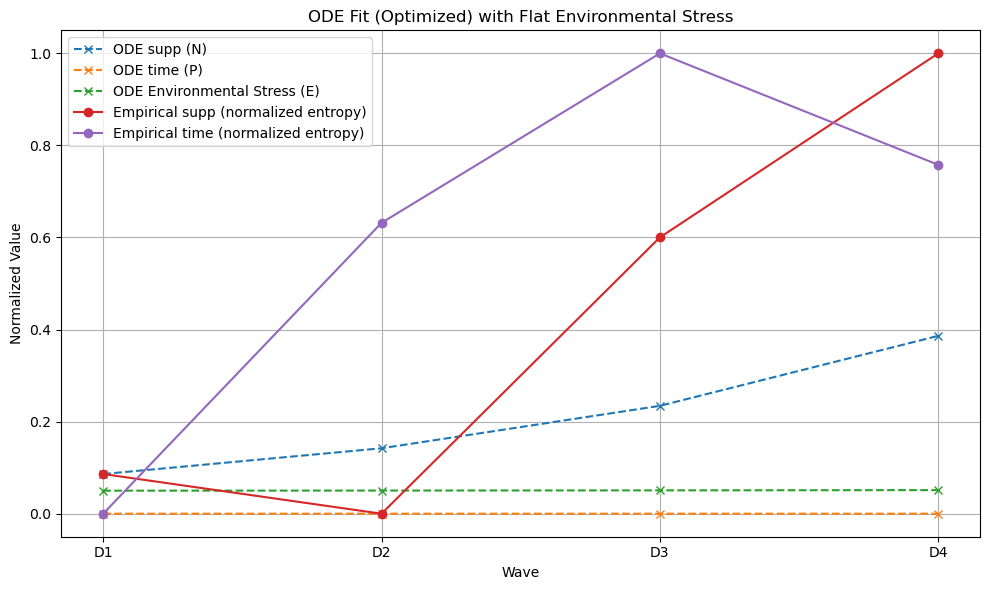

In [26]:
# MODULE B_3 (barley optimized, for illustrative purposes)

# Note: of the following scripts, if the user desires a 'working'
# ECTO model to 'play'/parameter-explore, utilize this module, B_3

# Note: This module is able to run via L-BFGS-B Optimization,
# or with Manual Parameter fitting (L-BFGS-B default shown)

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# ---------------------------------
# Toggle: Use Optimizer or Manual
# ---------------------------------
use_optimizer = True  # <<< Set to True to use L-BFGS-B; False for manual parameters

# ---------------------------------
# Entropy Data (values collected in MODULES B_0 through B_2)
# ---------------------------------
waves = ["D1", "D2", "D3", "D4"]
trait_x = "supp"
trait_y = "time"

supp_entropy = np.array([1.7278, 1.7198, 1.7755, 1.8126], dtype=float)  # X-series
time_entropy = np.array([1.4530, 1.6855, 1.8210, 1.7319], dtype=float)  # Y-series

# Use evenly spaced indices as the model time axis (D1..D4 → t = 0,1,2,3)
t_data = np.arange(len(waves), dtype=float)

def normalize(arr):
    arr = np.asarray(arr, dtype=float)
    rng = arr.max() - arr.min()
    return (arr - arr.min()) / rng if rng != 0 else np.zeros_like(arr)

N_empirical = normalize(supp_entropy)
P_empirical = normalize(time_entropy)

# ---------------------------------
# ODE System (fixed E_stress form)
# ---------------------------------
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K):
    N, P, E = y
    E_dynamic = c1 * P + c2 * N + c3 * E  # linear combination, as in original
    dNdt = mu * N - alpha * N**2 - (beta**2) * N * P
    dPdt = mu * P - beta * P * E_dynamic
    dEdt = gamma * E * (N / (N + K)) if (N + K) != 0 else 0.0
    return [dNdt, dPdt, dEdt]

# ---------------------------------
# Initial Conditions
# ---------------------------------
_eps = 1e-6  # tiny epsilon to avoid P(0)=0 invariant
init_conditions = [max(N_empirical[0], _eps), max(P_empirical[0], _eps), 0.05]

# ---------------------------------
# Objective Function (SSE on N, P)
# ---------------------------------
def objective(params):
    mu, alpha, beta, gamma, c1, c2, c3, K = params
    sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
    N_model, P_model = sol[:, 0], sol[:, 1]
    error_N = np.sum((N_model - N_empirical)**2)
    error_P = np.sum((P_model - P_empirical)**2)
    return error_N + error_P

# ---------------------------------
# Choose Parameters
# ---------------------------------
if use_optimizer:
    initial_guess = [0.0002, 0.1, 0.2, 0.03, 1.0, 0.45, 0.0, 0.5]
    bounds = [
        (1e-5, 0.50),   # mu
        (1e-4, 1.00),   # alpha
        (0.001, 0.60),  # beta
        (0.005, 0.60),  # gamma
        (0.10, 2.50),   # c1
        (0.10, 2.50),   # c2
        (0.00, 2.00),   # c3
        (0.10, 2.00),   # K
    ]
    result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')
    mu, alpha, beta, gamma, c1, c2, c3, K = result.x
else:
    # MANUAL PARAMETER EXPLORATION (engages when 'use_optimizer' is False)
    mu    = 10.8
    alpha = 6.8
    beta  = 2.16031
    gamma = 2.1
    c1    = 12.0
    c2    = 1.21
    c3    = 21.50     # << Try changing this to see effect of E_stress feedback
    K     = 0.5

# ---------------------------------
# Simulate System
# ---------------------------------
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
N_model, P_model, E_model = sol.T

# ---------------------------------
# Validation Metrics
# ---------------------------------
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)
rN, pN = pearsonr(N_empirical, N_model)
try:
    rP, pP = pearsonr(P_empirical, P_model)
except Exception:
    rP, pP = np.nan, np.nan

# DTW (same minimalist implementation as in script)
def dtw_distance(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n+1):
        ai = a[i-1]
        for j in range(1, m+1):
            cost = abs(ai - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return float(D[n, m])

dtwN = dtw_distance(N_empirical, N_model)
dtwP = dtw_distance(P_empirical, P_model)

# ---------------------------------
# Output
# ---------------------------------
print(f"\n{'Optimized' if use_optimizer else 'Manual'} Parameters:")
print(f"mu = {mu:.5f}, alpha = {alpha: .5f}, beta = {beta:.5f}, gamma = {gamma:.5f}, "
      f"c1 = {c1:.5f}, c2 = {c2:.5f}, c3 = {c3:.5f}, K = {K:.5f}")

print(f"\nValidation Metrics:")
print(f"RMSE for {trait_x}: {rmse_N:.4f}")
print(f"RMSE for {trait_y}: {rmse_P:.4f}")
print(f"R² for {trait_x}:  {r2_N:.4f}")
print(f"R² for {trait_y}:  {r2_P:.4f}")
print(f"Pearson r (N): {rN:.3f} (p={pN:.3f})")
print(f"Pearson r (P): {rP:.3f} (p={pP:.3f})")
print(f"DTW distance (N): {dtwN:.4f}")
print(f"DTW distance (P): {dtwP:.4f}")

# ---------------------------------
# Plot
# ---------------------------------
plt.figure(figsize=(10, 6))
x = np.arange(len(waves))
plt.plot(x, N_model, 'x--', label=f'ODE {trait_x} (N)')
plt.plot(x, P_model, 'x--', label=f'ODE {trait_y} (P)')
plt.plot(x, E_model, 'x--', label='ODE Environmental Stress (E)')
plt.plot(x, N_empirical, 'o-', label=f'Empirical {trait_x} (normalized entropy)')
plt.plot(x, P_empirical, 'o-', label=f'Empirical {trait_y} (normalized entropy)')
plt.title(f"ODE Fit ({'Optimized' if use_optimizer else 'Manual'}) with Flat Environmental Stress")
plt.xlabel("Wave")
plt.ylabel("Normalized Value")
plt.xticks(x, waves)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Optimizer status: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
Final SSE: 0.8453668435809853

Optimized Parameters:
mu = 1.01069, alpha =  0.45500, beta = 0.01000, gamma = 2.08849, c1 = 0.80000, c2 = 1.07893, c3 = 0.77866, K = 0.52894, E0 = 0.03000

Validation Metrics:
RMSE for supp: 0.1183
RMSE for time: 0.7024
R² for supp:  0.9148
R² for time:  -2.6151
Pearson r (N): 0.965 (p=0.035)
Pearson r (P): 0.516 (p=0.484)


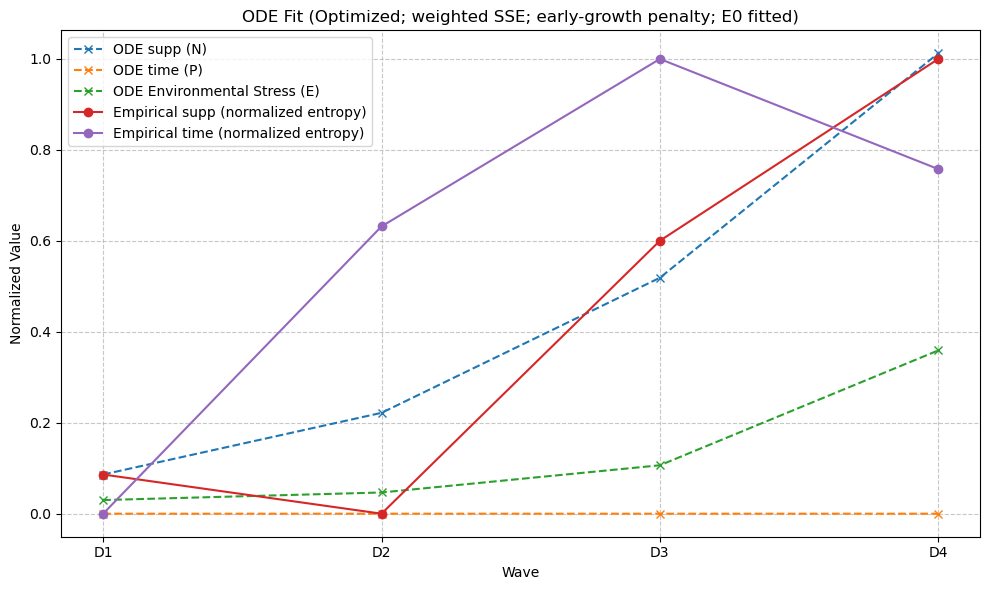

In [28]:
# MODULE B_4 ('weakly' optimized for illustrative purposes)

# ECTO Nonlinear ODE System; D1–D4 entropy only
# Optimizer with E0, weighted SSE, and early-growth penalty for P 

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# -----------------------------
# Data (8 numbers)
# -----------------------------
waves = ["D1","D2","D3","D4"]
trait_x = "supp"
trait_y = "time"
supp_entropy = np.array([1.7278, 1.7198, 1.7755, 1.8126], dtype=float)
time_entropy = np.array([1.4530, 1.6855, 1.8210, 1.7319], dtype=float)
t_data = np.arange(len(waves), dtype=float)

def normalize(a):
    a = np.asarray(a, float)
    r = a.max() - a.min()
    return (a - a.min())/r if r != 0 else np.zeros_like(a)

N_empirical = normalize(supp_entropy)
P_empirical = normalize(time_entropy)

# -----------------------------
# Model
# -----------------------------
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K):
    N, P, E = y
    E_dynamic = c1*P + c2*N + c3*E
    dNdt = mu*N - alpha*N**2 - (beta**2)*N*P
    dPdt = mu*P - beta*P*E_dynamic
    dEdt = gamma*E*(N/(N+K)) if (N+K) != 0 else 0.0
    return [dNdt, dPdt, dEdt]

# ---------------------------
# Optimizer (adds E0, weighted SSE, early-growth penalty)
# ---------------------------
wN, wP = 1.0, 0.40   # emphasize N
eps = 1e-6
delta = 0.15         # target early growth for P
lam   = 10.0         # penalty strength

# ---------------------------
# ECTO ODE SYSTEM
# ---------------------------
def objective(params):
    mu, alpha, beta, gamma, c1, c2, c3, K, E0 = params
    y0 = [max(N_empirical[0], eps), max(P_empirical[0], eps), E0]
    sol = odeint(system, y0, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
    N_model, P_model = sol[:,0], sol[:,1]
    errN = np.sum((N_model - N_empirical)**2)
    errP = np.sum((P_model - P_empirical)**2)

    # early growth rate r0 = mu - beta*(c1*P0 + c2*N0 + c3*E0)
    N0, P0 = y0[0], y0[1]
    r0 = mu - beta*(c1*P0 + c2*N0 + c3*E0)
    pen = max(0.0, delta - r0)**2

    return wN*errN + wP*errP + lam*pen

# start near preselected 'neighborhood' but allow P to grow
initial_guess = [1.01, 0.45, 0.20, 2.10, 0.80, 1.10, 0.80, 0.50, 0.12]
bounds = [
    (0.05, 3.5),   # mu
    (0.001, 2.5),  # alpha
    (0.01, 0.50),  # beta  (cap to avoid over-damping)
    (0.05, 3.0),   # gamma
    (0.10, 1.00),  # c1
    (0.10, 1.50),  # c2
    (0.00, 1.20),  # c3
    (0.10, 1.00),  # K
    (0.03, 0.40),  # E0
]

result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')
mu, alpha, beta, gamma, c1, c2, c3, K, E0 = result.x
init_conditions = [max(N_empirical[0], eps), max(P_empirical[0], eps), float(E0)]

print("Optimizer status:", result.message)
print("Final SSE:", result.fun)

# ---------------------------
# Simulate with optimized params
# ---------------------------
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
N_model, P_model, E_model = sol.T

# ---------------------------
# Metrics
# ---------------------------
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)
rN, pN = pearsonr(N_empirical, N_model)
try:
    rP, pP = pearsonr(P_empirical, P_model)
except Exception:
    rP, pP = np.nan, np.nan

print(f"\nOptimized Parameters:")
print(f"mu = {mu:.5f}, alpha = {alpha: .5f}, beta = {beta:.5f}, gamma = {gamma:.5f}, "
      f"c1 = {c1:.5f}, c2 = {c2:.5f}, c3 = {c3:.5f}, K = {K:.5f}, E0 = {E0:.5f}")

print("\nValidation Metrics:")
print(f"RMSE for {trait_x}: {rmse_N:.4f}")
print(f"RMSE for {trait_y}: {rmse_P:.4f}")
print(f"R² for {trait_x}:  {r2_N:.4f}")
print(f"R² for {trait_y}:  {r2_P:.4f}")
print(f"Pearson r (N): {rN:.3f} (p={pN:.3f})")
print(f"Pearson r (P): {rP:.3f} (p={pP:.3f})")

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(10,6))
x = np.arange(len(waves))
plt.plot(x, N_model, 'x--', label=f'ODE {trait_x} (N)')
plt.plot(x, P_model, 'x--', label=f'ODE {trait_y} (P)')
plt.plot(x, E_model, 'x--', label='ODE Environmental Stress (E)')
plt.plot(x, N_empirical, 'o-', label=f'Empirical {trait_x} (normalized entropy)')
plt.plot(x, P_empirical, 'o-', label=f'Empirical {trait_y} (normalized entropy)')
plt.title("ODE Fit (Optimized; weighted SSE; early-growth penalty; E0 fitted)")
plt.xlabel("Wave"); plt.ylabel("Normalized Value")
plt.xticks(x, waves)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


Optimizer status: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Final SSE: 0.43443909337958453

Optimized Parameters:
mu = 2.04391, alpha =  2.42469, beta = 0.01350, gamma = 3.00000, c1 = 0.53194, c2 = 0.56730, c3 = 1.11481, K = 0.10000, E0 = 0.33103

Validation Metrics:
RMSE for supp: 0.2256
RMSE for time: 0.2402
R² for supp:  0.6900
R² for time:  0.5771
Pearson r (N): 0.872 (p=0.128)
Pearson r (P): 0.857 (p=0.143)


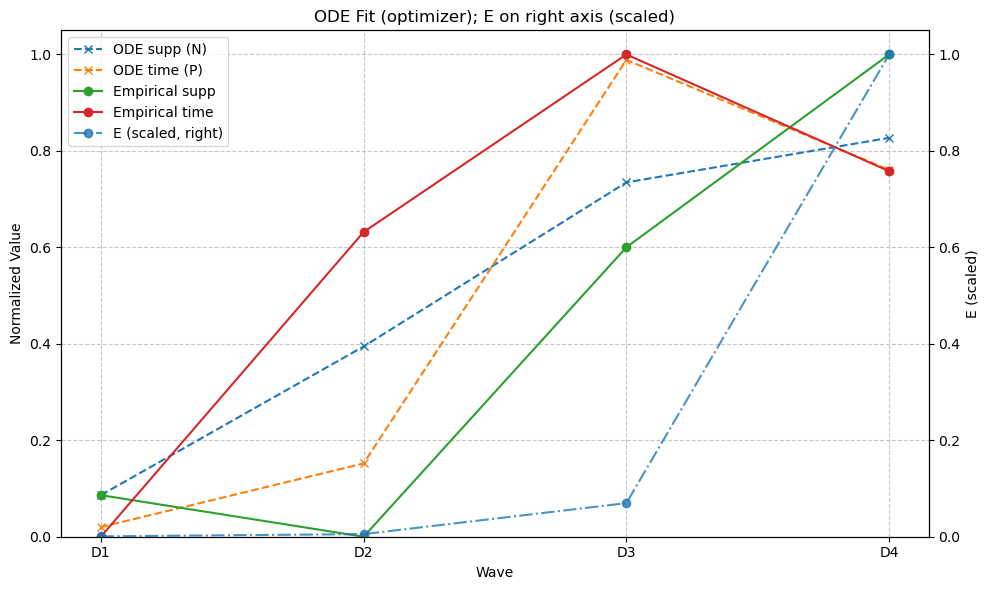

In [30]:
# MODULE B_5, fully optimized for illustrative purposes
# See MODULES [A_(n)] or full ECTO preprint for further explanation

# Optimizer to move P; E on separate (right) axis, scaled for display
# Uses only D1–D4 entropy numbers; no file I/O.

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# ---------------- Data ----------------
# Entropy values from MODULE B_2 are input values here:

waves = ["D1","D2","D3","D4"]
trait_x, trait_y = "supp", "time"
supp_entropy = np.array([1.7278, 1.7198, 1.7755, 1.8126], float)
time_entropy = np.array([1.4530, 1.6855, 1.8210, 1.7319], float)
t_data = np.arange(4, dtype=float)

def normalize(a):
    a = np.asarray(a, float); r = a.max()-a.min()
    return (a-a.min())/r if r>0 else np.zeros_like(a)

N_empirical = normalize(supp_entropy)
P_empirical = normalize(time_entropy)

# ---------------- Model ----------------
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K):
    N, P, E = y
    E_dyn = c1*P + c2*N + c3*E
    dNdt = mu*N - alpha*N**2 - (beta**2)*N*P
    dPdt = mu*P - beta*P*E_dyn
    dEdt = gamma*E*(N/(N+K)) if (N+K)!=0 else 0.0
    return [dNdt, dPdt, dEdt]

# ------------- Optimizer --------------
# weights / penalties to encourage P: rise to D3, soft dip at D4
wN, wP = 1.0, 1.0
eps = 1e-6
delta_up  = 0.20  # positive early growth rate target
delta_amp = 0.07  # P1>P0+delta, P2>P1+delta
delta_dip = 0.03  # P3 < P2 - delta
lam_r0    = 10.0
lam_mono  = 8.0

def objective(params):
    mu, alpha, beta, gamma, c1, c2, c3, K, E0 = params
    y0 = [max(N_empirical[0], 0.02), max(P_empirical[0], 0.02), E0]
    sol = odeint(system, y0, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
    N_mod, P_mod = sol[:,0], sol[:,1]

    errN = np.sum((N_mod - N_empirical)**2)
    errP = np.sum((P_mod - P_empirical)**2)

    # early growth rate at t0
    N0, P0 = y0[0], y0[1]
    r0 = mu - beta*(c1*P0 + c2*N0 + c3*E0)
    pen_r0 = max(0.0, delta_up - r0)**2

    # shape penalties: rise then dip
    pen_rise1 = max(0.0, (P0 + delta_amp) - P_mod[1])**2
    pen_rise2 = max(0.0, (P_mod[1] + delta_amp) - P_mod[2])**2
    pen_dip   = max(0.0, (P_mod[3] - (P_mod[2] - delta_dip)))**2

    return wN*errN + wP*errP + lam_r0*pen_r0 + lam_mono*(pen_rise1 + pen_rise2 + pen_dip)

initial_guess = [1.0, 0.45, 0.15, 2.0, 0.7, 1.1, 0.6, 0.5, 0.12]  # [mu,alpha,beta,gamma,c1,c2,c3,K,E0]
bounds = [
    (0.10, 6.0),  # mu
    (0.001, 3.0), # alpha
    (0.01, 0.35), # beta
    (0.05, 3.0),  # gamma
    (0.10, 1.20), # c1
    (0.10, 1.60), # c2
    (0.00, 1.20), # c3
    (0.10, 1.20), # K
    (0.05, 0.40), # E0
]

res = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')
mu, alpha, beta, gamma, c1, c2, c3, K, E0 = res.x
init_conditions = [max(N_empirical[0], 0.02), max(P_empirical[0], 0.02), float(E0)]

print("Optimizer status:", res.message)
print("Final SSE:", res.fun)

# ------------- Simulate ---------------
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
N_model, P_model, E_model = sol.T

# --------------- Metrics --------------
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)
rN, pN = pearsonr(N_empirical, N_model)
try:
    rP, pP = pearsonr(P_empirical, P_model)
except Exception:
    rP, pP = np.nan, np.nan

print(f"\nOptimized Parameters:")
print(f"mu = {mu:.5f}, alpha = {alpha: .5f}, beta = {beta:.5f}, gamma = {gamma:.5f}, "
      f"c1 = {c1:.5f}, c2 = {c2:.5f}, c3 = {c3:.5f}, K = {K:.5f}, E0 = {E0:.5f}")

print("\nValidation Metrics:")
print(f"RMSE for {trait_x}: {rmse_N:.4f}")
print(f"RMSE for {trait_y}: {rmse_P:.4f}")
print(f"R² for {trait_x}:  {r2_N:.4f}")
print(f"R² for {trait_y}:  {r2_P:.4f}")
print(f"Pearson r (N): {rN:.3f} (p={pN:.3f})")
print(f"Pearson r (P): {rP:.3f} (p={pP:.3f})")

# ---------------- Plot (E on right axis, scaled) ----------------
plt.figure(figsize=(10,6))
x = np.arange(4)

ax1 = plt.gca()
ln1 = ax1.plot(x, N_model, 'x--', label=f'ODE {trait_x} (N)')
ln2 = ax1.plot(x, P_model, 'x--', label=f'ODE {trait_y} (P)')
ln3 = ax1.plot(x, N_empirical, 'o-', label=f'Empirical {trait_x}')
ln4 = ax1.plot(x, P_empirical, 'o-', label=f'Empirical {trait_y}')
ax1.set_xlabel("Wave"); ax1.set_ylabel("Normalized Value")
ax1.set_xticks(x, waves); ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
E_plot = E_model / (np.max(E_model) if np.max(E_model)>0 else 1.0)
ln5 = ax2.plot(x, E_plot, 'o-.', alpha=0.8, label='E (scaled, right)')
ax2.set_ylabel("E (scaled)"); ax2.set_ylim(0, 1.05)

lines = ln1 + ln2 + ln3 + ln4 + ln5
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.title("ODE Fit (optimizer); E on right axis (scaled)")
plt.tight_layout()
plt.show()



=== LOO (hold one wave) ===
Hold D1 | N_true=0.086 N_pred=0.086 | P_true=0.000 P_pred=0.020 | CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Hold D2 | N_true=0.000 N_pred=0.417 | P_true=0.632 P_pred=0.158 | CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Hold D3 | N_true=0.600 N_pred=0.811 | P_true=1.000 P_pred=0.770 | CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Hold D4 | N_true=1.000 N_pred=0.662 | P_true=0.758 P_pred=0.962 | CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH

LOO RMSE — N: 0.2884 | P: 0.2825

=== Full-data (reduced-fit + β,c1 free) ===
Optimizer: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH | SSE=0.488128
Params (μ,α,γ,E0,β,c1) = [2.1228749390990105, 2.579933319451765, 3.0, 0.4, 0.05687160096316685, 0.1]
Fixed (c2,c3,K) = [0.1, 1.2, 0.3]
RMSE N=0.2341 (R²=0.6662) | RMSE P=0.2367 (R²=0.5895)


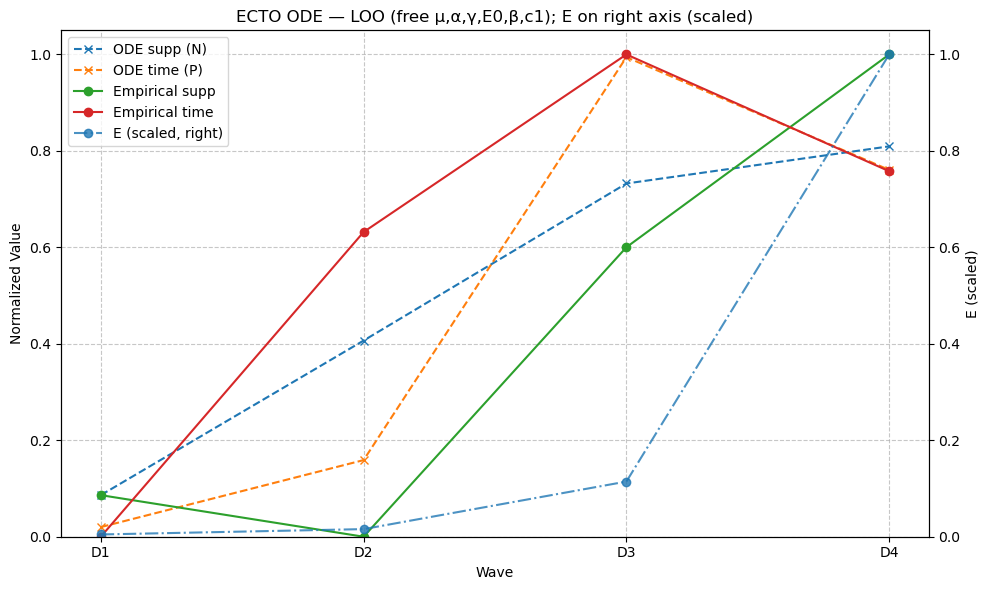

In [41]:
## MODULE B_6 : Statistical Validation I
# Leave-One-Out Cross-Validation with Partial Parameter Fitting 

# Fits μ, α, γ, E₀, β, and c₁ using LOO across waves; c₂, c₃, and K fixed.  
# Evaluates predictive error by holding out each wave in turn.  
# Plots ODE trajectories for N (supp), P (time), with scaled E on the right axis.

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, r2_score

# ---------------- Data ----------------
waves = ["D1","D2","D3","D4"]
trait_x, trait_y = "supp", "time"
supp_entropy = np.array([1.7278, 1.7198, 1.7755, 1.8126], float)
time_entropy = np.array([1.4530, 1.6855, 1.8210, 1.7319], float)
t_full = np.arange(4, dtype=float)

def normalize(a):
    a = np.asarray(a, float); r = a.max()-a.min()
    return (a-a.min())/r if r>0 else np.zeros_like(a)

N_emp = normalize(supp_entropy)
P_emp = normalize(time_entropy)

# ---------------- Model ----------------
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K):
    N, P, E = y
    E_dyn = c1*P + c2*N + c3*E
    dNdt = mu*N - alpha*N**2 - (beta**2)*N*P
    dPdt = mu*P - beta*P*E_dyn
    dEdt = gamma*E*(N/(N+K)) if (N+K)!=0 else 0.0
    return [dNdt, dPdt, dEdt]

# ---------------- Fixed (kept from full-fit neighborhood) ----------------
C2_FIX   = 0.10
C3_FIX   = 1.20
K_FIX    = 0.30

# ---------------- LOO optimizer pieces ----------------
wN, wP = 1.0, 1.2     # give P a bit more weight
eps = 1e-6
delta_up, delta_amp, delta_dip = 0.20, 0.07, 0.03
lam_r0, lam_shape = 10.0, 8.0

# Free params: [mu, alpha, gamma, E0, beta, c1]
bounds = [
    (0.10, 6.0),   # mu
    (0.001, 3.0),  # alpha
    (0.05, 3.0),   # gamma
    (0.05, 0.40),  # E0
    (0.02, 0.35),  # beta  (let interaction matter)
    (0.10, 1.20),  # c1    (P's weight in E_dynamic)
]

def objective(params, obs_idx):
    mu, alpha, gamma, E0, beta, c1 = params
    y0 = [max(N_emp[0], 0.02), max(P_emp[0], 0.02), E0]
    sol = odeint(system, y0, t_full, args=(mu, alpha, beta, gamma, c1, C2_FIX, C3_FIX, K_FIX))
    N_mod, P_mod = sol[:,0], sol[:,1]

    errN = np.sum((N_mod[obs_idx] - N_emp[obs_idx])**2)
    errP = np.sum((P_mod[obs_idx] - P_emp[obs_idx])**2)

    # encourage early P growth and rise→peak→dip shape
    N0, P0 = y0[0], y0[1]
    r0 = mu - beta*(c1*P0 + C2_FIX*N0 + C3_FIX*E0)
    pen_r0  = max(0.0, delta_up - r0)**2
    pen_r1  = max(0.0, (P0 + delta_amp) - P_mod[1])**2
    pen_r2  = max(0.0, (P_mod[1] + delta_amp) - P_mod[2])**2
    pen_dip = max(0.0, (P_mod[3] - (P_mod[2] - delta_dip)))**2

    return wN*errN + wP*errP + lam_r0*pen_r0 + lam_shape*(pen_r1 + pen_r2 + pen_dip)

def fit_fold(obs_idx, x0=None):
    if x0 is None:
        # seed close to good full-fit but allow β,c1 to shape P
        x0 = [1.0, 0.45, 2.0, 0.12, 0.12, 0.60]  # [mu, alpha, gamma, E0, beta, c1]
    res = minimize(lambda p: objective(p, obs_idx), x0, bounds=bounds, method='L-BFGS-B')
    return res

def simulate(params):
    mu, alpha, gamma, E0, beta, c1 = params
    y0 = [max(N_emp[0], 0.02), max(P_emp[0], 0.02), float(E0)]
    sol = odeint(system, y0, t_full, args=(mu, alpha, beta, gamma, c1, C2_FIX, C3_FIX, K_FIX))
    return sol.T  # N_model, P_model, E_model

# ---------------- LOO ----------------
all_idx = np.arange(4)
print("=== LOO (hold one wave) ===")
held = []
for hold in all_idx:
    obs_idx = np.delete(all_idx, hold)
    res = fit_fold(obs_idx)
    N_mod, P_mod, _ = simulate(res.x)
    out = (waves[hold], float(N_emp[hold]), float(N_mod[hold]), float(P_emp[hold]), float(P_mod[hold]), res.message)
    held.append(out)
    print(f"Hold {out[0]} | N_true={out[1]:.3f} N_pred={out[2]:.3f} | P_true={out[3]:.3f} P_pred={out[4]:.3f} | {out[5]}")

N_rmse = np.sqrt(np.mean([(h[2]-h[1])**2 for h in held]))
P_rmse = np.sqrt(np.mean([(h[4]-h[3])**2 for h in held]))
print(f"\nLOO RMSE — N: {N_rmse:.4f} | P: {P_rmse:.4f}")

# ---------------- Full-data refit (same free params) ----------------
res_full = fit_fold(all_idx)
params_full = res_full.x
N_model, P_model, E_model = simulate(params_full)

rmse_N = np.sqrt(mean_squared_error(N_emp, N_model))
rmse_P = np.sqrt(mean_squared_error(P_emp, P_model))
r2_N = r2_score(N_emp, N_model)
r2_P = r2_score(P_emp, P_model)

print("\n=== Full-data (reduced-fit + β,c1 free) ===")
print(f"Optimizer: {res_full.message} | SSE={res_full.fun:.6f}")
print(f"Params (μ,α,γ,E0,β,c1) = {[float(x) for x in params_full]}")
print(f"Fixed (c2,c3,K) = {[C2_FIX, C3_FIX, K_FIX]}")
print(f"RMSE N={rmse_N:.4f} (R²={r2_N:.4f}) | RMSE P={rmse_P:.4f} (R²={r2_P:.4f})")

# ---------------- Plot (E on right axis, scaled) ----------------
plt.figure(figsize=(10,6))
x = np.arange(4)

ax1 = plt.gca()
ln1 = ax1.plot(x, N_model, 'x--', label=f'ODE {trait_x} (N)')
ln2 = ax1.plot(x, P_model, 'x--', label=f'ODE {trait_y} (P)')
ln3 = ax1.plot(x, N_emp, 'o-', label=f'Empirical {trait_x}')
ln4 = ax1.plot(x, P_emp, 'o-', label=f'Empirical {trait_y}')
ax1.set_xlabel("Wave"); ax1.set_ylabel("Normalized Value")
ax1.set_xticks(x, waves); ax1.grid(True, linestyle='--', alpha=0.7); ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
E_plot = E_model / (np.max(E_model) if np.max(E_model)>0 else 1.0)
ln5 = ax2.plot(x, E_plot, 'o-.', alpha=0.8, label='E (scaled, right)')
ax2.set_ylabel("E (scaled)"); ax2.set_ylim(0, 1.05)

lines = ln1 + ln2 + ln3 + ln4 + ln5
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.title("ECTO ODE — LOO (free μ,α,γ,E0,β,c1); E on right axis (scaled)")
plt.tight_layout()
plt.show()


In [43]:
# MODULE B_7: Statistical Validation II

# Local Identifiability Check (±10% Sensitivity Around Full-Data Params)
# Evaluates stability of μ, α, γ, E₀, β, c₁ by perturbing each parameter ±10%.  
# Reports changes in RMSE (total, N, P) to assess parameter identifiability.

import numpy as np

# Use the full-data params that were just fit in the main cell
mu_f, alpha_f, gamma_f, E0_f, beta_f, c1_f = params_full  # from script
theta_names = ["mu","alpha","gamma","E0","beta","c1"]
theta0 = np.array([mu_f, alpha_f, gamma_f, E0_f, beta_f, c1_f], float)

def total_rmse_from_params(params_vec):
    mu, alpha, gamma, E0, beta, c1 = params_vec
    y0 = [max(N_emp[0], 0.02), max(P_emp[0], 0.02), float(E0)]
    sol = odeint(system, y0, t_full, args=(mu, alpha, beta, gamma, c1, C2_FIX, C3_FIX, K_FIX))
    N_mod, P_mod = sol[:,0], sol[:,1]
    rmseN = np.sqrt(mean_squared_error(N_emp, N_mod))
    rmseP = np.sqrt(mean_squared_error(P_emp, P_mod))
    return float(np.sqrt(0.5*(rmseN**2 + rmseP**2))), float(rmseN), float(rmseP)

base_total, baseN, baseP = total_rmse_from_params(theta0)

rows = []
for i, name in enumerate(theta_names):
    for frac, label in [(+0.10, "+10%"), (-0.10, "−10%")]:
        th = theta0.copy()
        th[i] = theta0[i] * (1.0 + frac)
        tot, rN, rP = total_rmse_from_params(th)
        rel = 100.0 * (tot - base_total) / base_total
        rows.append((name, label, base_total, tot, rel, rN, rP))

print("Param  |  Δ   | RMSE_total(base)  RMSE_total(pert)   Δ%     RMSE_N  RMSE_P")
for r in rows:
    print(f"{r[0]:6s} | {r[1]:>3s} |      {r[2]:.4f}           {r[3]:.4f}     {r[4]:+6.1f}%   {r[5]:.4f}  {r[6]:.4f}")


Param  |  Δ   | RMSE_total(base)  RMSE_total(pert)   Δ%     RMSE_N  RMSE_P
mu     | +10% |      0.2354           0.2933      +24.6%   0.2674  0.3170
mu     | −10% |      0.2354           0.2657      +12.9%   0.2237  0.3019
alpha  | +10% |      0.2354           0.2472       +5.0%   0.2380  0.2561
alpha  | −10% |      0.2354           0.2466       +4.7%   0.2410  0.2520
gamma  | +10% |      0.2354           0.3153      +34.0%   0.2340  0.3796
gamma  | −10% |      0.2354           0.4844     +105.8%   0.2343  0.6437
E0     | +10% |      0.2354           0.2441       +3.7%   0.2341  0.2538
E0     | −10% |      0.2354           0.2501       +6.2%   0.2341  0.2651
beta   | +10% |      0.2354           0.2443       +3.8%   0.2341  0.2540
beta   | −10% |      0.2354           0.2503       +6.3%   0.2341  0.2655
c1     | +10% |      0.2354           0.2354       +0.0%   0.2341  0.2367
c1     | −10% |      0.2354           0.2354       -0.0%   0.2341  0.2367


In [45]:
# MODULE B_8: Statistical Validation III

# Multistart Optimization Robustness Check
# Tests stability of parameter estimates by jittering the full-data solution (± 20%)  
# and re-fitting from multiple random seeds. 
# Reports SSE distribution and fitted parameters.

import numpy as np

seeds = [1, 11, 21, 31, 41, 51, 61, 71]
sses = []
thetas = []

for sd in seeds:
    rng = np.random.default_rng(sd)
    # jitter around full-data solution (±20%)
    jitter = 1.0 + 0.20 * rng.uniform(-1, 1, size=len(params_full))
    x0 = params_full * jitter  # [mu, alpha, gamma, E0, beta, c1]
    res = minimize(lambda p: objective(p, np.arange(4)), x0, bounds=bounds, method='L-BFGS-B')
    sses.append(float(res.fun))
    thetas.append(res.x)

sses = np.array(sses)
print(f"Multistart SSE — mean={sses.mean():.6f}, sd={sses.std():.6f}, "
      f"min={sses.min():.6f}, max={sses.max():.6f}")

# (Optional) print a compact param table
for i, th in enumerate(thetas):
    print(f"Seed {seeds[i]:>2}: {['%.4f'%v for v in th]}")


Multistart SSE — mean=0.488149, sd=0.000048, min=0.488128, max=0.488274
Seed  1: ['2.1256', '2.5943', '3.0000', '0.3957', '0.0573', '0.3256']
Seed 11: ['2.1229', '2.5799', '3.0000', '0.4000', '0.0569', '0.1000']
Seed 21: ['2.1229', '2.5799', '3.0000', '0.4000', '0.0569', '0.1000']
Seed 31: ['2.1229', '2.5799', '3.0000', '0.4000', '0.0569', '0.1000']
Seed 41: ['2.1228', '2.5795', '3.0000', '0.4000', '0.0569', '0.1000']
Seed 51: ['2.1229', '2.5799', '3.0000', '0.4000', '0.0569', '0.1000']
Seed 61: ['2.1233', '2.5809', '3.0000', '0.4000', '0.0568', '0.1389']
Seed 71: ['2.1229', '2.5799', '3.0000', '0.4000', '0.0569', '0.1000']


In [ ]:
## TRACK A CONTINUED BELOW: 

In [61]:
# MODULE A_8: Script for a Visual for the Appendix
# in place of the ORIGINAL Figure 1 on p.7 of MAIN

## needs to be two or three traits, Shannon entropy y-axis; time on x-axis



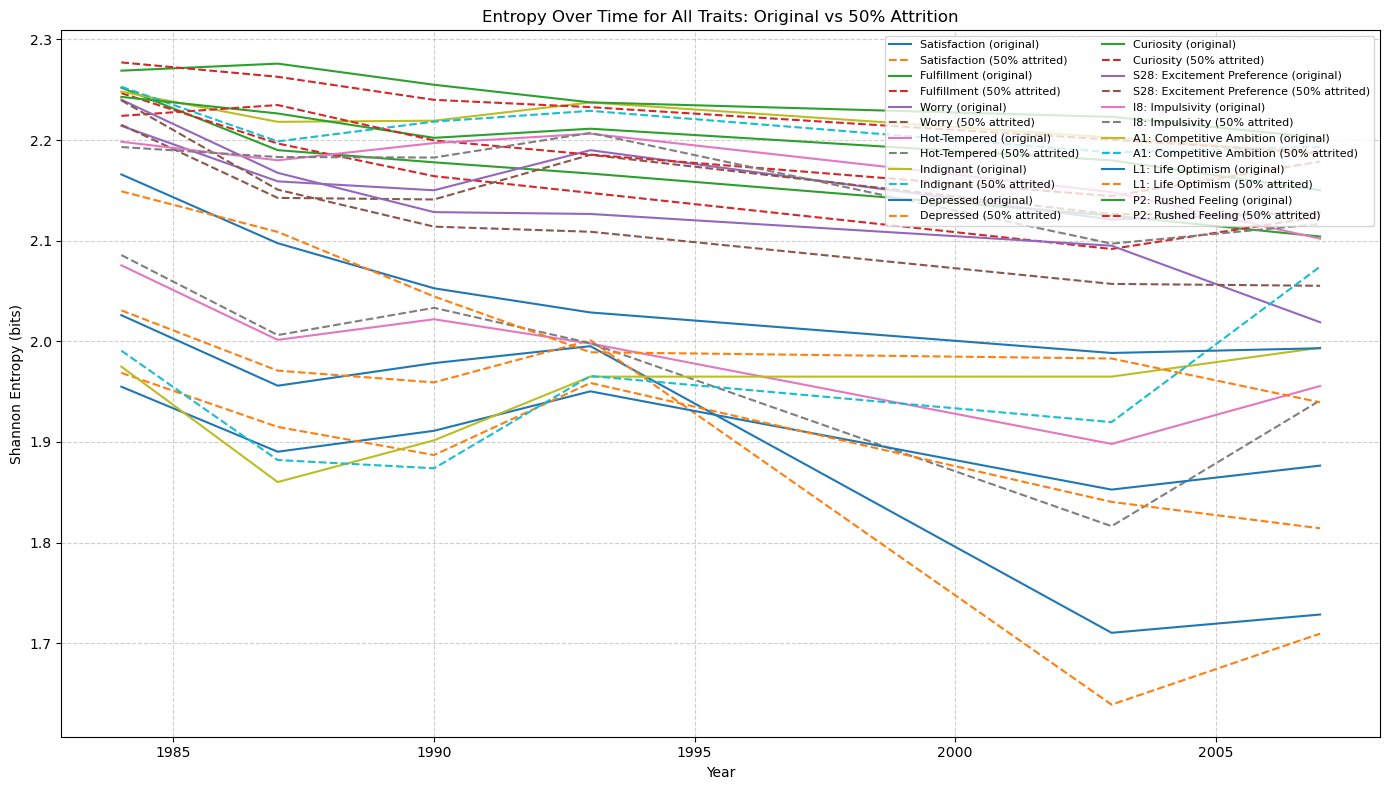

In [65]:
# MODULE 9_A
#
# Accompaniment for supplemental material, 
# APPENDIX B: Entropy Stability Under Simulated Attrition
#
# This script generates the data for Supplementary Table 1.
#
# APPENDIX B: Entropy Stability Under Simulated Attrition
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
import random

# === Full trait dataset ===
trait_data = {
    "Satisfaction": [
        [76, 231, 294, 611, 698],
        [48, 146, 248, 523, 593],
        [40, 125, 288, 480, 489],
        [29, 158, 289, 447, 480],
        [92, 443, 156, 68, 15],
        [85, 354, 138, 40, 17]
    ],
    "Fulfillment": [
        [193, 348, 445, 539, 382],
        [114, 252, 448, 447, 291],
        [106, 230, 423, 424, 240],
        [92, 212, 461, 344, 290],
        [40, 110, 239, 235, 149],
        [25, 95, 197, 189, 126]
    ],
    "Worry": [
        [159, 374, 325, 548, 527],
        [95, 241, 300, 476, 448],
        [74, 229, 309, 455, 359],
        [85, 250, 316, 391, 364],
        [29, 133, 175, 250, 185],
        [22, 113, 171, 179, 144]
    ],
    "Hot-Tempered": [
        [124, 249, 287, 473, 780],
        [73, 162, 280, 360, 683],
        [60, 156, 254, 376, 576],
        [43, 179, 243, 350, 586],
        [12, 75, 137, 214, 335],
        [17, 59, 119, 178, 259]
    ],
    "Indignant": [
        [185, 457, 334, 524, 415],
        [114, 332, 312, 448, 345],
        [101, 337, 329, 381, 280],
        [112, 353, 305, 344, 289],
        [53, 163, 204, 217, 139],
        [38, 139, 166, 176, 109]
    ],
    "Depressed": [
        [103, 159, 269, 527, 855],
        [54, 105, 251, 450, 700],
        [38, 98, 263, 464, 563],
        [40, 114, 265, 453, 535],
        [13, 52, 135, 253, 323],
        [9, 43, 127, 200, 246]
    ],
    "Curiosity": [
        [229, 520, 295, 310, 218],
        [116, 371, 402, 346, 287],
        [97, 343, 401, 319, 237],
        [99, 327, 385, 334, 245],
        [44, 196, 207, 189, 125],
        [31, 164, 193, 136, 103]
    ],
    "S28: Excitement Preference": [
        [168, 408, 514, 468, 348],
        [107, 365, 502, 360, 211],
        [94, 343, 505, 309, 168],
        [91, 341, 505, 285, 174],
        [38, 180, 287, 166, 101],
        [28, 140, 266, 128, 67]
    ],
    "I8: Impulsivity": [
        [189, 332, 263, 584, 556],
        [108, 241, 313, 457, 450],
        [110, 228, 294, 452, 343],
        [113, 236, 284, 437, 351],
        [46, 117, 181, 266, 165],
        [27, 84, 154, 214, 154],
    ],
    "A1: Competitive Ambition": [
        [78, 190, 318, 501, 836],
        [38, 98, 279, 455, 700],
        [34, 97, 292, 402, 600],
        [36, 131, 302, 368, 570],
        [16, 72, 184, 207, 297],
        [11, 67, 171, 170, 213],
    ],
    "L1: Life Optimism": [
        [278, 656, 515, 322, 156],
        [154, 444, 589, 238, 137],
        [117, 393, 569, 231, 112],
        [97, 363, 578, 264, 104],
        [36, 219, 316, 138, 63],
        [31, 156, 270, 121, 53],
    ],
    "P2: Rushed Feeling": [
        [337, 573, 274, 429, 312],
        [207, 435, 293, 368, 269],
        [149, 369, 310, 365, 237],
        [133, 411, 299, 327, 238],
        [54, 183, 185, 190, 162],
        [44, 146, 135, 191, 116]
    ]
}

years = [1984, 1987, 1990, 1993, 2003, 2007]

# Compute Shannon entropy
def compute_entropy(dist):
    total = sum(dist)
    if total == 0:
        return 0
    probs = [x / total for x in dist if x > 0]
    return -sum(p * np.log2(p) for p in probs)

# Apply dropout
def apply_attrition(dist, dropout_rate=0.5):
    np.random.seed(42)
    return [[np.random.binomial(count, 1 - dropout_rate) for count in wave] for wave in dist]

# Compute entropy curves
entropy_curves_original = {}
entropy_curves_attrited = {}

for trait, dist in trait_data.items():
    entropy_original = [compute_entropy(wave) for wave in dist]
    entropy_attrited = [compute_entropy(wave) for wave in apply_attrition(dist)]
    entropy_curves_original[trait] = entropy_original
    entropy_curves_attrited[trait] = entropy_attrited

# Plot
plt.figure(figsize=(14, 8))
for trait in trait_data:
    plt.plot(years, entropy_curves_original[trait], linestyle='-', label=f"{trait} (original)")
    plt.plot(years, entropy_curves_attrited[trait], linestyle='--', label=f"{trait} (50% attrited)")

plt.title("Entropy Over Time for All Traits: Original vs 50% Attrition")
plt.xlabel("Year")
plt.ylabel("Shannon Entropy (bits)")
plt.legend(fontsize=8, loc='upper right', ncol=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


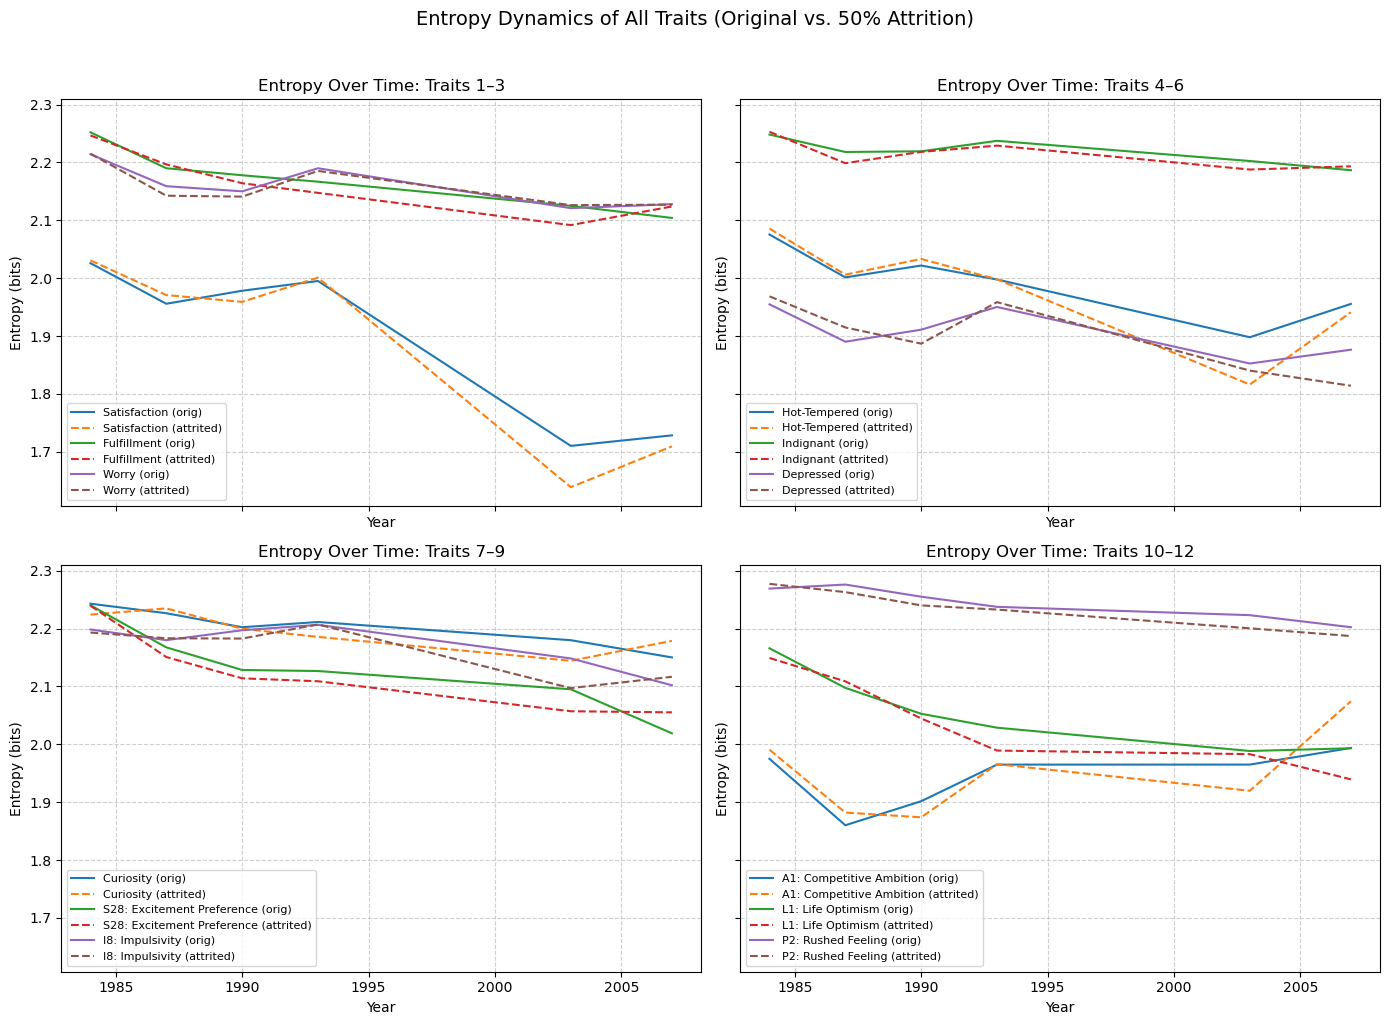

In [67]:
# MODULE A_9B
#
# Accompaniment for supplemental material, 
# APPENDIX B: Entropy Stability Under Simulated Attrition
#
# This script generates Supplementary Figure 2.
#
import numpy as np
import matplotlib.pyplot as plt

# === Assume trait_data, years, and compute_entropy/apply_attrition are defined as above ===

# === Compute entropy for original and attrited data ===
entropy_curves_original = {}
entropy_curves_attrited = {}

for trait, dist in trait_data.items():
    entropy_original = [compute_entropy(wave) for wave in dist]
    entropy_attrited = [compute_entropy(wave) for wave in apply_attrition(dist)]
    entropy_curves_original[trait] = entropy_original
    entropy_curves_attrited[trait] = entropy_attrited

# === Setup subplots ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

# === Organize traits into 4 groups of 3 ===
trait_groups = [
    ["Satisfaction", "Fulfillment", "Worry"],
    ["Hot-Tempered", "Indignant", "Depressed"],
    ["Curiosity", "S28: Excitement Preference", "I8: Impulsivity"],
    ["A1: Competitive Ambition", "L1: Life Optimism", "P2: Rushed Feeling"]
]

# === Plot each group ===
for i, group in enumerate(trait_groups):
    ax = axes[i]
    for trait in group:
        ax.plot(years, entropy_curves_original[trait], label=f"{trait} (orig)", linestyle='-')
        ax.plot(years, entropy_curves_attrited[trait], label=f"{trait} (attrited)", linestyle='--')
    ax.set_title(f"Entropy Over Time: Traits {3*i+1}–{3*i+3}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Entropy (bits)")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=8)

plt.suptitle("Entropy Dynamics of All Traits (Original vs. 50% Attrition)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



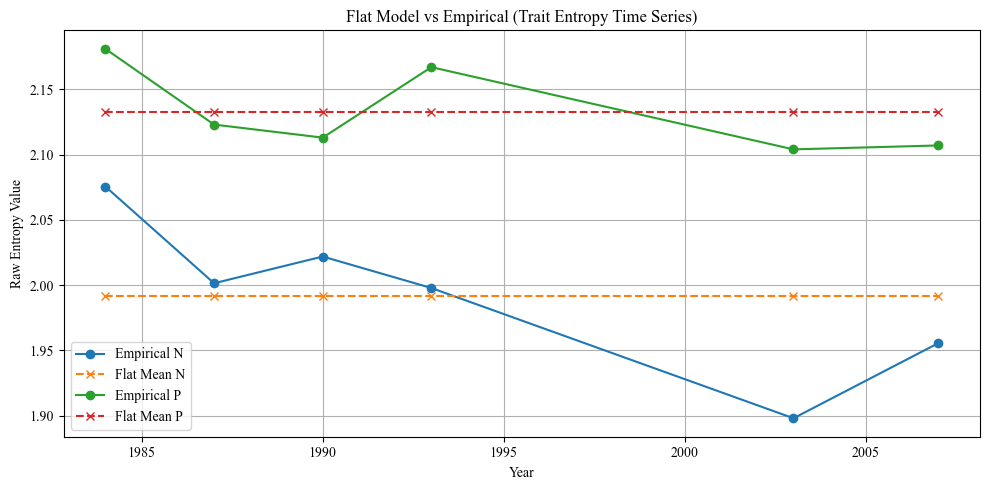

{'Flat Mean Results': {'P8 Hot-Tempered (N)': {'RMSE': 0.055011614547647074,
   'R^2': 0.0},
  'P4 Worry (P)': {'RMSE': 0.03020899424564361, 'R^2': 0.0}}}

In [69]:
# MODULE A_10
# From APPENDIX C.1: Model Evaluation: Null vs. ECTO Dynamical Systems
# For generating the data and figure in Supplementary Table 2,
# and Supplementary Figure 3, respectively.
#
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"
# Empirical data 
N_empirical = np.array([2.075515, 2.001416, 2.021902, 1.997771, 1.897984, 1.955553])
P_empirical = np.array([2.181, 2.123, 2.113, 2.167, 2.104, 2.107])
years = np.array([1984, 1987, 1990, 1993, 2003, 2007])

# Compute Mean AFTER Normalization 
mean_N = np.mean(N_empirical)
mean_P = np.mean(P_empirical)

# Flat Mean Baseline Model 
N_flat = np.full_like(N_empirical, mean_N)
P_flat = np.full_like(P_empirical, mean_P)

# RMSE and R^2 
rmse_N_flat = np.sqrt(mean_squared_error(N_empirical, N_flat))
rmse_P_flat = np.sqrt(mean_squared_error(P_empirical, P_flat))
r2_N_flat = r2_score(N_empirical, N_flat)
r2_P_flat = r2_score(P_empirical, P_flat)

# Plot Comparison
plt.figure(figsize=(10, 5))
plt.plot(years, N_empirical, 'o-', label='Empirical N')
plt.plot(years, N_flat, 'x--', label='Flat Mean N')
plt.plot(years, P_empirical, 'o-', label='Empirical P')
plt.plot(years, P_flat, 'x--', label='Flat Mean P')
plt.xlabel("Year")
plt.ylabel("Raw Entropy Value")
plt.title("Flat Model vs Empirical (Trait Entropy Time Series)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Return numeric validation
{
    "Flat Mean Results": {
        "P8 Hot-Tempered (N)": {
            "RMSE": rmse_N_flat,
            "R^2": r2_N_flat
        },
        "P4 Worry (P)": {
            "RMSE": rmse_P_flat,
            "R^2": r2_P_flat
        }
    }
}


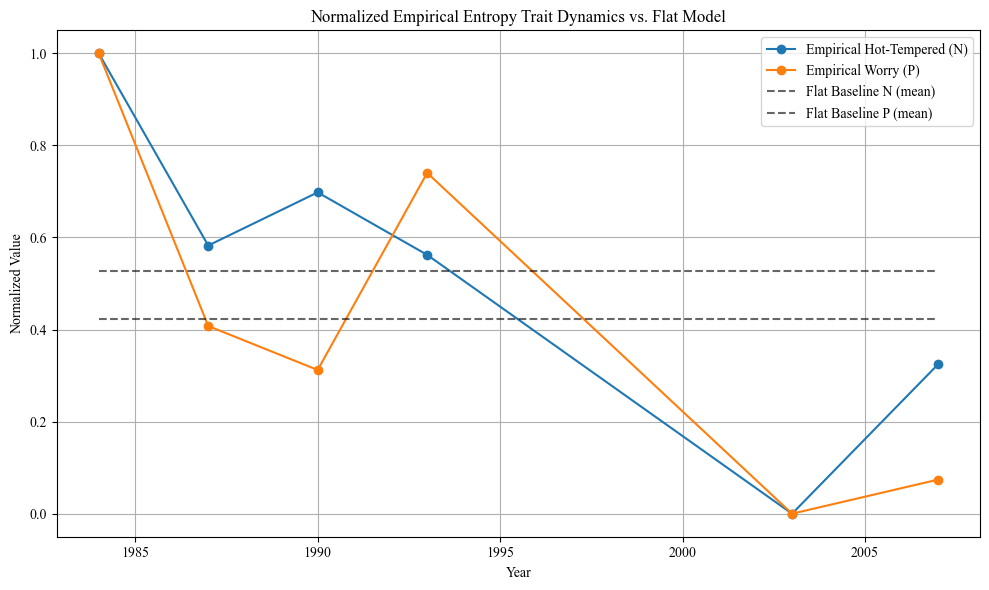

Flat Model Validation Metrics:
P8 Hot-Tempered (N): RMSE = 0.3098, R² = 0.0000
P4 Worry (P):        RMSE = 0.3528, R² = 0.0000


In [73]:
# MODULE A_11
# For generating additional data in Supplemental Table 2
# Model Evaluation: Null vs. ECTO Dynamical Systems
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

# Load entropy data
data = {
    "Year": [1984, 1987, 1990, 1993, 2003, 2007],
    "P9 Satisfaction": [2.0260, 1.9559, 1.9783, 1.9952, 1.7102, 1.7284],
    "L10 Fulfillment": [2.2521, 2.1900, 2.1779, 2.1668, 2.1250, 2.1041],
    "P4 Worry": [2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279],
    "P8 Hot-Tempered": [2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556],
    "P11 Indignant": [2.2481, 2.2181, 2.2193, 2.2374, 2.2025, 2.1867],
    "L11 Depressed": [1.9549, 1.8902, 1.9110, 1.9503, 1.8526, 1.8764],
    "N49 Curiosity": [2.2429, 2.2265, 2.2022, 2.2113, 2.1799, 2.1501],
    "S28 Excitement Preference": [2.2402, 2.1675, 2.1284, 2.1266, 2.0950, 2.0190],
    "I8 Impulsivity": [2.1984, 2.1799, 2.1970, 2.2063, 2.1483, 2.1020],
    "A1 Competitive Ambition": [1.9748, 1.8601, 1.9016, 1.9649, 1.9649, 1.9936],
    "L1 Life Optimism": [2.1659, 2.0975, 2.0527, 2.0287, 1.9884, 1.9931],
    "P2 Rushed Feeling": [2.2690, 2.2760, 2.2550, 2.2375, 2.2231, 2.2023],
}
df = pd.DataFrame(data)

# Normalize data
def normalize(arr):
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

years = df["Year"].values
t_data = years - years[0]
N_empirical = normalize(df["P8 Hot-Tempered"].values)
P_empirical = normalize(df["P4 Worry"].values)

# Mean and variance lines for overlay
mean_N = np.mean(N_empirical)
mean_P = np.mean(P_empirical)
var_N = np.var(N_empirical)
var_P = np.var(P_empirical)

# Simulate a basic "flat model" baseline for comparison
N_flat = np.full_like(N_empirical, mean_N)
P_flat = np.full_like(P_empirical, mean_P)

# Plotting overlay with "flat model" baseline
plt.figure(figsize=(10, 6))
plt.plot(years, N_empirical, 'o-', label='Empirical Hot-Tempered (N)')
plt.plot(years, P_empirical, 'o-', label='Empirical Worry (P)')
plt.plot(years, N_flat, 'k--', label='Flat Baseline N (mean)', alpha=0.6)
plt.plot(years, P_flat, 'k--', label='Flat Baseline P (mean)', alpha=0.6)
plt.title("Normalized Empirical Entropy Trait Dynamics vs. Flat Model")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === RMSE and R² for Flat Model ===
rmse_N_flat = np.sqrt(mean_squared_error(N_empirical, N_flat))
rmse_P_flat = np.sqrt(mean_squared_error(P_empirical, P_flat))
r2_N_flat = r2_score(N_empirical, N_flat)
r2_P_flat = r2_score(P_empirical, P_flat)

# === Print Results ===
print("Flat Model Validation Metrics:")
print(f"P8 Hot-Tempered (N): RMSE = {rmse_N_flat:.4f}, R² = {r2_N_flat:.4f}")
print(f"P4 Worry (P):        RMSE = {rmse_P_flat:.4f}, R² = {r2_P_flat:.4f}")


Running global optimization with alpha tuning...

 Optimized Parameters (via differential_evolution with alpha):
mu = 0.01000, alpha = 0.01000, beta = 0.01000, gamma = 0.01066
c1 = 0.10000, c2 = 0.52314, c3 = 0.01011, K = 1.96388

Validation Metrics:
RMSE for P8 Hot-Tempered: 0.1343
RMSE for P4 Worry: 0.0221
R² for P8 Hot-Tempered: -4.9623
R² for P4 Worry: 0.5496
Pearson r (N): 0.871 (p=0.024)
Pearson r (P): 0.800 (p=0.056)
DTW distance (N): 0.486
DTW distance (P): 0.095


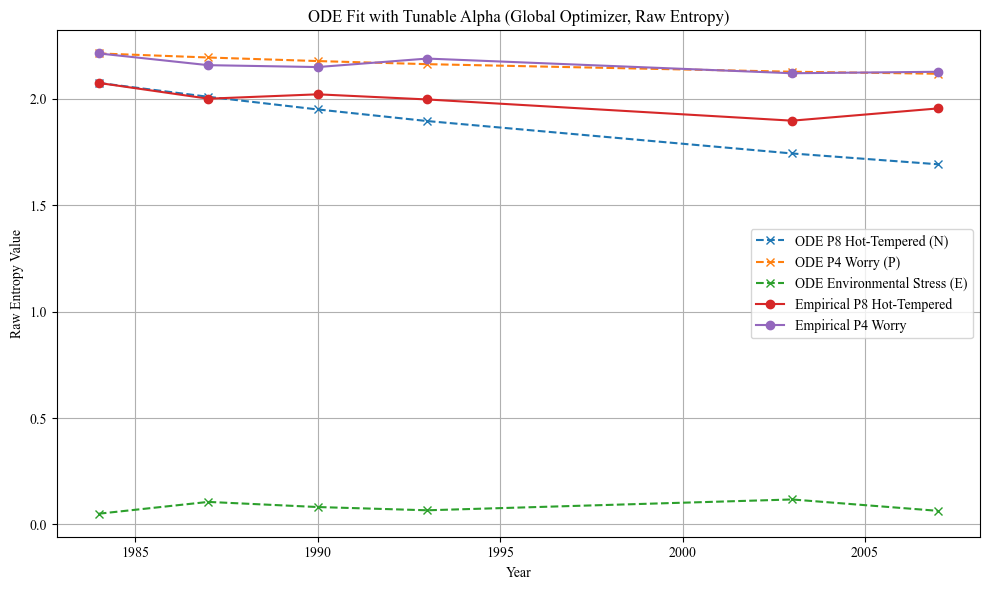

In [71]:
# MODULE A_12
# For generating Supplemental Figure 4
#
# Global Optimizer with Tunable Alpha (Raw Entropy)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import differential_evolution
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

#  Raw Entropy Data 
data = {
    "Year": [1984, 1987, 1990, 1993, 2003, 2007],
    "P9 Satisfaction": [2.0260, 1.9559, 1.9783, 1.9952, 1.7102, 1.7284],
    "L10 Fulfillment": [2.2521, 2.1900, 2.1779, 2.1668, 2.1250, 2.1041],
    "P4 Worry": [2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279],
    "P8 Hot-Tempered": [2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556],
    "P11 Indignant": [2.2481, 2.2181, 2.2193, 2.2374, 2.2025, 2.1867],
    "L11 Depressed": [1.9549, 1.8902, 1.9110, 1.9503, 1.8526, 1.8764],
    "N49 Curiosity": [2.2429, 2.2265, 2.2022, 2.2113, 2.1799, 2.1501],
    "S28: Excitement Preference": [2.2402, 2.1675, 2.1284, 2.1266, 2.0950, 2.0190],
    "I8: Impulsivity": [2.1984, 2.1799, 2.1970, 2.2063, 2.1483, 2.1020],
    "A1: Competitive Ambition": [1.9748, 1.8601, 1.9016, 1.9649, 1.9649, 1.9936],
    "L1: Life Optimism": [2.1659, 2.0975, 2.0527, 2.0287, 1.9884, 1.9931],
    "P2: Rushed Feeling": [2.2690, 2.2760, 2.2550, 2.2375, 2.2231, 2.2023]
}
df = pd.DataFrame(data)

# Trait Pair Selection 
trait_x = "P8 Hot-Tempered"
trait_y = "P4 Worry"

years = np.array(df["Year"])
t_data = years - years[0]
N_empirical = df[trait_x].values
P_empirical = df[trait_y].values
init_conditions = [N_empirical[0], P_empirical[0], 0.05]

# ODE System (now with alpha) 
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K):
    N, P, E = y
    omega = 0.8
    amplitude = 0.05
    E_dynamic = c1 * P + c2 * N + c3 * E
    dNdt = mu * N - alpha * N**2 - beta**2 * N * P
    dPdt = mu * P - beta * P * E_dynamic
    dEdt = gamma * E * (N / (N + K)) + amplitude * 0.5 * np.sin(omega * t)
    return [dNdt, dPdt, dEdt]

# Objective Function with Penalty 
def objective(params):
    mu, alpha, beta, gamma, c1, c2, c3, K = params
    try:
        sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
        N, P, E = sol.T
        if np.any(np.isnan(N)) or np.any(np.abs(N) > 10) or np.any(np.abs(P) > 10):
            return 1e6
        error_N = np.sum((N - N_empirical)**2)
        error_P = np.sum((P - P_empirical)**2)
        return error_N + error_P
    except:
        return 1e6

# Wide Bounds (including alpha) 
bounds = [
    (1e-6, 0.01),   # mu
    (0.01, 1.0),    # alpha (formerly fixed at 0.15)
    (0.01, 0.5),    # beta
    (0.01, 0.5),    # gamma
    (0.1, 2.0),     # c1
    (0.1, 2.0),     # c2
    (0.01, 2.0),    # c3
    (0.2, 2.0)      # K
]

# Run Global Optimization 
print("Running global optimization with alpha tuning...")
result = differential_evolution(objective, bounds, maxiter=2000, tol=1e-6, seed=42)
mu, alpha, beta, gamma, c1, c2, c3, K = result.x

# Final Simulation with Optimal Parameters 
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
N_model, P_model, E_model = sol.T

# Validation Metrics 
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)
rN, pN = pearsonr(N_empirical, N_model)
rP, pP = pearsonr(P_empirical, P_model)

# DTW Function 
def dtw_distance(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

dtwN = dtw_distance(N_empirical, N_model)
dtwP = dtw_distance(P_empirical, P_model)

# Output
print(f"\n Optimized Parameters (via differential_evolution with alpha):")
print(f"mu = {mu:.5f}, alpha = {alpha:.5f}, beta = {beta:.5f}, gamma = {gamma:.5f}")
print(f"c1 = {c1:.5f}, c2 = {c2:.5f}, c3 = {c3:.5f}, K = {K:.5f}")
print(f"\nValidation Metrics:")
print(f"RMSE for {trait_x}: {rmse_N:.4f}")
print(f"RMSE for {trait_y}: {rmse_P:.4f}")
print(f"R² for {trait_x}: {r2_N:.4f}")
print(f"R² for {trait_y}: {r2_P:.4f}")
print(f"Pearson r (N): {rN:.3f} (p={pN:.3f})")
print(f"Pearson r (P): {rP:.3f} (p={pP:.3f})")
print(f"DTW distance (N): {dtwN:.3f}")
print(f"DTW distance (P): {dtwP:.3f}")


# Plot
plt.figure(figsize=(10, 6))
plt.plot(years, N_model, 'x--', label=f'ODE {trait_x} (N)')
plt.plot(years, P_model, 'x--', label=f'ODE {trait_y} (P)')
plt.plot(years, E_model, 'x--', label='ODE Environmental Stress (E)')
plt.plot(years, N_empirical, 'o-', label=f'Empirical {trait_x}')
plt.plot(years, P_empirical, 'o-', label=f'Empirical {trait_y}')
plt.title("ODE Fit with Tunable Alpha (Global Optimizer, Raw Entropy)")
plt.xlabel("Year")
plt.ylabel("Raw Entropy Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



R² min (N): -12.544
R² max (N): -1.415 at α = 0.150, β = 0.250
R² mean (N): -3.525 ± 2.574
0/400 combinations had R² (N) > 0.5 (0.0%)
R² min (P): -1.651
R² max (P): -1.430 at α = 0.150, β = 0.134
R² mean (P): -1.515 ± 0.061
0/400 combinations had R² (P) > 0.5 (0.0%)


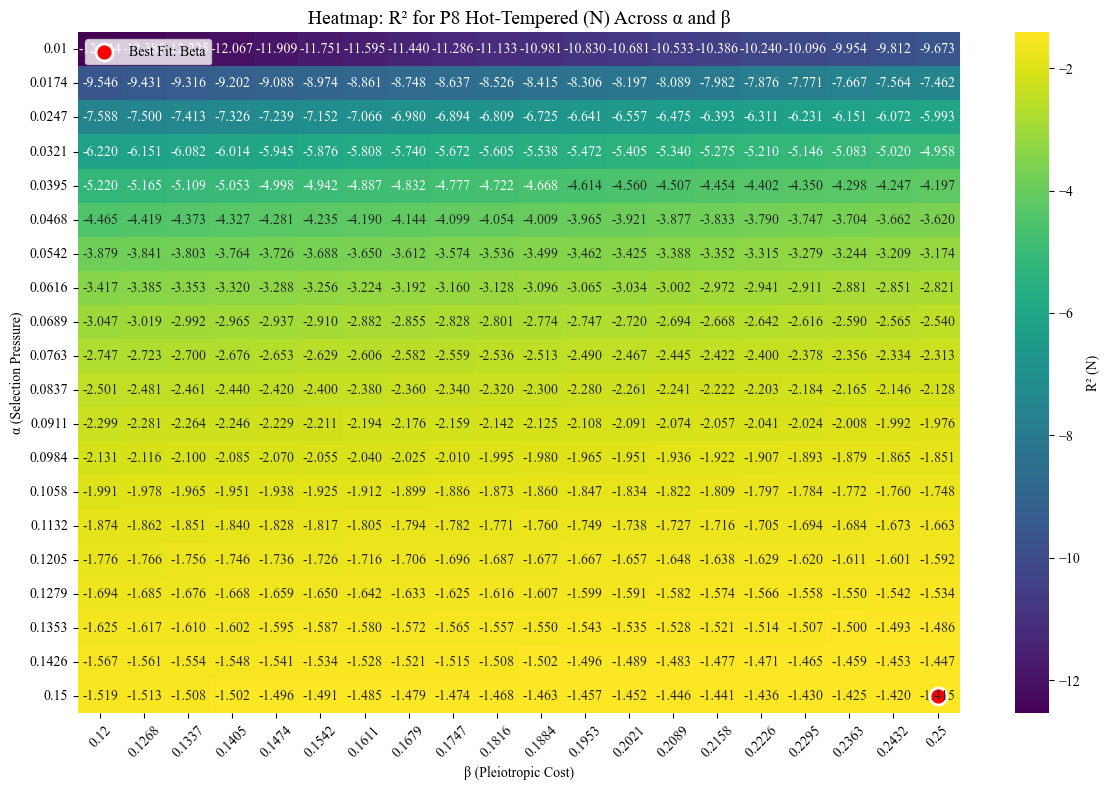

In [79]:
# MODULE A_13
# From APPENDIX C.2: Parameter Sensitivity
# 
# For generaing Supplemental Figure 5.
#
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

# Sweep alpha and beta
alpha_values = np.linspace(0.01, 0.15, 20)  # α = selection cost
beta_values = np.linspace(0.12, 0.25, 20)   # β = pleiotropic penalty

r2_results_N = np.zeros((len(alpha_values), len(beta_values)))
r2_results_P = np.zeros((len(alpha_values), len(beta_values)))
rmse_results_N = np.zeros_like(r2_results_N)
rmse_results_P = np.zeros_like(r2_results_P)

# Fixed parameters
mu = 0.00001
gamma = 0.03
c1 = 2.0
c2 = 0.21
c3 = 5.60  # ← Environmental stress term: unperturbed
K = 0.5

# Updated ODE to use alpha dynamically
def system_sweep(y, t, mu, alpha, beta, gamma, c1, c2, c3, K):
    N, P, E = y
    omega = 0.8
    amplitude = 0.05
    E_dynamic = c1 * P + c2 * N + c3 * E
    dNdt = mu * N - alpha * N**2 - beta**2 * N * P
    dPdt = mu * P - beta * P * E_dynamic
    dEdt = gamma * E * (N / (N + K)) + amplitude * 0.5 * np.sin(omega * t)
    return [dNdt, dPdt, dEdt]

# Perform sweep
for i, alpha in enumerate(alpha_values):
    for j, beta in enumerate(beta_values):
        sol = odeint(system_sweep, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K))
        N_model, P_model, _ = sol.T

        r2_results_N[i, j] = r2_score(N_empirical, N_model)
        r2_results_P[i, j] = r2_score(P_empirical, P_model)
        rmse_results_N[i, j] = np.sqrt(mean_squared_error(N_empirical, N_model))
        rmse_results_P[i, j] = np.sqrt(mean_squared_error(P_empirical, P_model))

alpha_labels = [round(a, 4) for a in alpha_values]
beta_labels = [round(b, 4) for b in beta_values]

r2_df_N = pd.DataFrame(r2_results_N, index=alpha_labels, columns=beta_labels)

plt.figure(figsize=(12, 8))
ax = sns.heatmap(r2_df_N, annot=True, fmt=".3f", cmap="viridis", cbar_kws={'label': 'R² (N)'})
plt.title("Heatmap: R² for P8 Hot-Tempered (N) Across α and β", fontsize=14)
plt.xlabel("β (Pleiotropic Cost)")
plt.ylabel("α (Selection Pressure)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Optional: Highlight best value
max_idx = np.unravel_index(np.argmax(r2_results_N), r2_results_N.shape)
best_alpha = alpha_labels[max_idx[0]]
best_beta = beta_labels[max_idx[1]]
plt.scatter(x=max_idx[1]+0.5, y=max_idx[0]+0.5, s=150, c="red", edgecolors="white", linewidth=2, label="Best Fit: Beta")
plt.legend(loc="upper left")

# Flatten for analysis N trait
r2_flat = r2_results_N.flatten()

# Basic statistics
r2_min = np.min(r2_flat)
r2_max = np.max(r2_flat)
r2_mean = np.mean(r2_flat)
r2_std = np.std(r2_flat)

# Best parameter combo
best_idx = np.unravel_index(np.argmax(r2_results_N), r2_results_N.shape)
best_alpha = alpha_values[best_idx[0]]
best_beta = beta_values[best_idx[1]]
best_r2 = r2_results_N[best_idx]

# Count how many parameter sets exceed a threshold (e.g., R² > 0.5)
threshold = 0.5
num_above_thresh = np.sum(r2_results_N > threshold)
total_tests = r2_results_N.size
percent_above = 100 * num_above_thresh / total_tests

# Report
print(f"R² min (N): {r2_min:.3f}")
print(f"R² max (N): {r2_max:.3f} at α = {best_alpha:.3f}, β = {best_beta:.3f}")
print(f"R² mean (N): {r2_mean:.3f} ± {r2_std:.3f}")
print(f"{num_above_thresh}/{total_tests} combinations had R² (N) > {threshold} ({percent_above:.1f}%)")

# Flatten for P (Worry)
r2_flat_P = r2_results_P.flatten()

# Basic stats for P
r2_min_P = np.min(r2_flat_P)
r2_max_P = np.max(r2_flat_P)
r2_mean_P = np.mean(r2_flat_P)
r2_std_P = np.std(r2_flat_P)

# Best (α, β) for P
best_idx_P = np.unravel_index(np.argmax(r2_results_P), r2_results_P.shape)
best_alpha_P = alpha_values[best_idx_P[0]]
best_beta_P = beta_values[best_idx_P[1]]
best_r2_P = r2_results_P[best_idx_P]

# Threshold count
threshold = 0.5
num_above_P = np.sum(r2_results_P > threshold)
total_tests = r2_results_P.size
percent_above_P = 100 * num_above_P / total_tests

# Print
print(f"R² min (P): {r2_min_P:.3f}")
print(f"R² max (P): {r2_max_P:.3f} at α = {best_alpha_P:.3f}, β = {best_beta_P:.3f}")
print(f"R² mean (P): {r2_mean_P:.3f} ± {r2_std_P:.3f}")
print(f"{num_above_P}/{total_tests} combinations had R² (P) > {threshold} ({percent_above_P:.1f}%)")


plt.tight_layout()
plt.show()


Parameters: mu=1e-05, alpha =0.15 , beta=0.16746, gamma=0.03, c1=2.0, c2=0.21, c3=5.6, K=0.5, G=1.0
RMSE: P2 Rushed Feeling=0.2088, P4 Worry=0.2509
R²: P2 Rushed Feeling=0.6438, P4 Worry=0.4941
Pearson r: P2 Rushed Feeling=0.865 (p=0.026), P4 Worry=0.798 (p=0.057)
DTW distance: P2 Rushed Feeling=0.546, P4 Worry=0.796


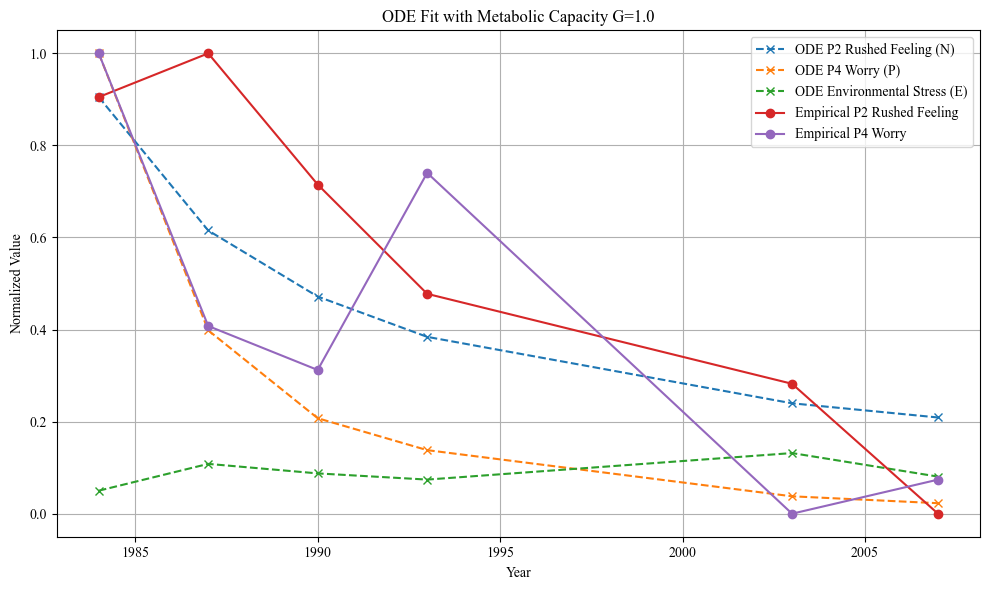

In [91]:
# MODULE A_15
# For Generating Supplemental Figure 6
# From: APPENDIX C.5: Metabolic Capacity Sensitivity Sweep
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# === Trait Entropy Data ===
data = {
    "Year": [1984, 1987, 1990, 1993, 2003, 2007],
    "P9 Satisfaction": [2.0260, 1.9559, 1.9783, 1.9952, 1.7102, 1.7284],
    "L10 Fulfillment": [2.2521, 2.1900, 2.1779, 2.1668, 2.1250, 2.1041],
    "P4 Worry": [2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279],
    "P8 Hot-Tempered": [2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556],
    "P11 Indignant": [2.2481, 2.2181, 2.2193, 2.2374, 2.2025, 2.1867],
    "L11 Depressed": [1.9549, 1.8902, 1.9110, 1.9503, 1.8526, 1.8764],
    "N49 Curiosity": [2.2429, 2.2265, 2.2022, 2.2113, 2.1799, 2.1501],
    "S28 Excitement Preference": [2.2402, 2.1675, 2.1284, 2.1266, 2.0950, 2.0190],
    "I8 Impulsivity": [2.1984, 2.1799, 2.1970, 2.2063, 2.1483, 2.1020],
    "A1 Competitive Ambition": [1.9748, 1.8601, 1.9016, 1.9649, 1.9649, 1.9936],
    "L1 Life Optimism": [2.1659, 2.0975, 2.0527, 2.0287, 1.9884, 1.9931],
    "P2 Rushed Feeling": [2.2690, 2.2760, 2.2550, 2.2375, 2.2231, 2.2023],
}

df = pd.DataFrame(data)
trait_x = "P2 Rushed Feeling"
trait_y = "P4 Worry"

years = np.array(df["Year"])
t_data = years - years[0]

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

N_empirical = normalize(df[trait_x].values)
P_empirical = normalize(df[trait_y].values)

# === Updated ODE System with metabolic capacity G ===
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K, G):
    N, P, E = y
    omega = 0.8
    amplitude = 0.05
    E_dynamic = c1 * P + c2 * N + c3 * E
    dNdt = mu * N - alpha * N**2 - beta**2 * N * P
    dPdt = mu * P - beta * P * (E_dynamic / G)
    dEdt = gamma * E * (N / (N + K)) + amplitude * 0.5 * np.sin(omega * t)
    return [dNdt, dPdt, dEdt]

# === Parameters ===
mu    = 0.00001
alpha = 0.15
beta  = 0.16746
gamma = 0.03
c1    = 2.0
c2    = 0.21
c3    = 5.60
K     = 0.5
G     = 1.0  # Can be varied for testing metabolic constraint

# === Initial Conditions and Simulation ===
init_conditions = [N_empirical[0], P_empirical[0], 0.05]
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K, G))
N_model, P_model, E_model = sol.T

# === Metrics ===
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)
rN, pN = pearsonr(N_empirical, N_model)
rP, pP = pearsonr(P_empirical, P_model)

# === DTW Function ===
def dtw_distance(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

dtwN = dtw_distance(N_empirical, N_model)
dtwP = dtw_distance(P_empirical, P_model)

# === Output ===
print(f"Parameters: mu={mu}, alpha ={alpha} , beta={beta}, gamma={gamma}, c1={c1}, c2={c2}, c3={c3}, K={K}, G={G}")
print(f"RMSE: {trait_x}={rmse_N:.4f}, {trait_y}={rmse_P:.4f}")
print(f"R²: {trait_x}={r2_N:.4f}, {trait_y}={r2_P:.4f}")
print(f"Pearson r: {trait_x}={rN:.3f} (p={pN:.3f}), {trait_y}={rP:.3f} (p={pP:.3f})")
print(f"DTW distance: {trait_x}={dtwN:.3f}, {trait_y}={dtwP:.3f}")

# === Plot ===
plt.figure(figsize=(10, 6))
plt.plot(years, N_model, 'x--', label=f'ODE {trait_x} (N)')
plt.plot(years, P_model, 'x--', label=f'ODE {trait_y} (P)')
plt.plot(years, E_model, 'x--', label='ODE Environmental Stress (E)')
plt.plot(years, N_empirical, 'o-', label=f'Empirical {trait_x}')
plt.plot(years, P_empirical, 'o-', label=f'Empirical {trait_y}')
plt.title(f"ODE Fit with Metabolic Capacity G={G}")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Parameters: mu=1e-05, alpha=0.15, beta=0.16746, gamma=0.03, c1=2.0, c2=0.21, c3=5.6, K=0.5, G=0.12
RMSE: P2 Rushed Feeling=0.1982, P4 Worry=0.3653
R²: P2 Rushed Feeling=0.6789, P4 Worry=-0.0718
Pearson r: P2 Rushed Feeling=0.879 (p=0.021), P4 Worry=0.735 (p=0.096)
DTW distance: P2 Rushed Feeling=0.514, P4 Worry=1.475


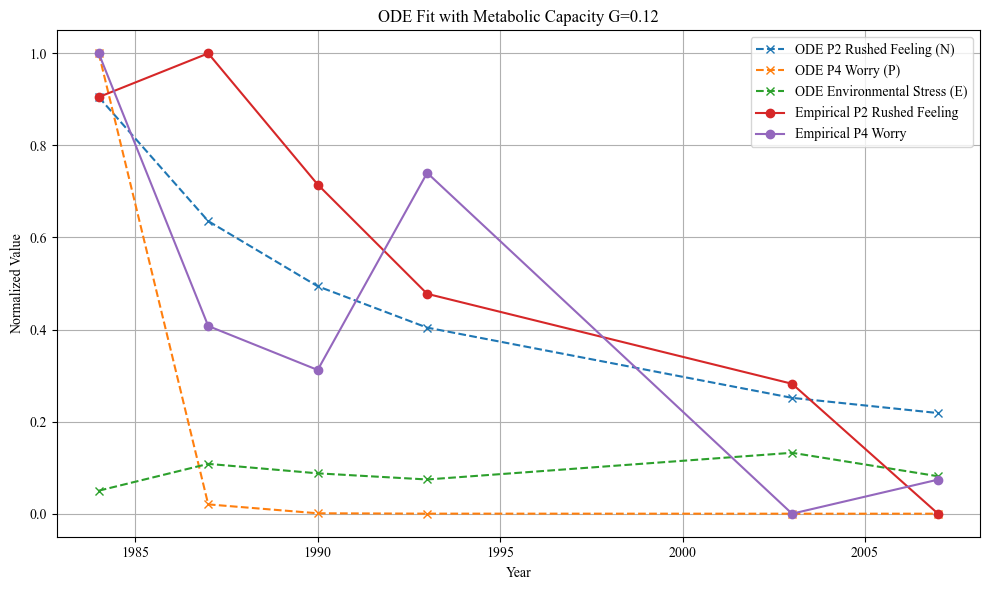

In [93]:
# MODULE A_16
# For Generating Supplemental Figure 7
# From: APPENDIX C.5: Metabolic Capacity Sensitivity Sweep
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# === Trait Entropy Data ===
data = {
    "Year": [1984, 1987, 1990, 1993, 2003, 2007],
    "P9 Satisfaction": [2.0260, 1.9559, 1.9783, 1.9952, 1.7102, 1.7284],
    "L10 Fulfillment": [2.2521, 2.1900, 2.1779, 2.1668, 2.1250, 2.1041],
    "P4 Worry": [2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279],
    "P8 Hot-Tempered": [2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556],
    "P11 Indignant": [2.2481, 2.2181, 2.2193, 2.2374, 2.2025, 2.1867],
    "L11 Depressed": [1.9549, 1.8902, 1.9110, 1.9503, 1.8526, 1.8764],
    "N49 Curiosity": [2.2429, 2.2265, 2.2022, 2.2113, 2.1799, 2.1501],
    "S28 Excitement Preference": [2.2402, 2.1675, 2.1284, 2.1266, 2.0950, 2.0190],
    "I8 Impulsivity": [2.1984, 2.1799, 2.1970, 2.2063, 2.1483, 2.1020],
    "A1 Competitive Ambition": [1.9748, 1.8601, 1.9016, 1.9649, 1.9649, 1.9936],
    "L1 Life Optimism": [2.1659, 2.0975, 2.0527, 2.0287, 1.9884, 1.9931],
    "P2 Rushed Feeling": [2.2690, 2.2760, 2.2550, 2.2375, 2.2231, 2.2023],
}

df = pd.DataFrame(data)
trait_x = "P2 Rushed Feeling"
trait_y = "P4 Worry"

years = np.array(df["Year"])
t_data = years - years[0]

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

N_empirical = normalize(df[trait_x].values)
P_empirical = normalize(df[trait_y].values)

# === Updated ODE System with metabolic capacity G ===
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K, G):
    N, P, E = y
    omega = 0.8
    amplitude = 0.05
    E_dynamic = c1 * P + c2 * N + c3 * E
    dNdt = mu * N - alpha * N**2 - beta**2 * N * P
    dPdt = mu * P - beta * P * (E_dynamic / G)
    dEdt = gamma * E * (N / (N + K)) + amplitude * 0.5 * np.sin(omega * t)
    return [dNdt, dPdt, dEdt]

# === Parameters ===
mu    = 0.00001
alpha = 0.15
beta  = 0.16746
gamma = 0.03
c1    = 2.0
c2    = 0.21
c3    = 5.60
K     = 0.5
G     = 0.120  # Can be varied for testing metabolic constraint

# === Initial Conditions and Simulation ===
init_conditions = [N_empirical[0], P_empirical[0], 0.05]
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K, G))
N_model, P_model, E_model = sol.T

# === Metrics ===
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)
rN, pN = pearsonr(N_empirical, N_model)
rP, pP = pearsonr(P_empirical, P_model)

# === DTW Function ===
def dtw_distance(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

dtwN = dtw_distance(N_empirical, N_model)
dtwP = dtw_distance(P_empirical, P_model)

# === Output ===
print(f"Parameters: mu={mu}, alpha={alpha}, beta={beta}, gamma={gamma}, c1={c1}, c2={c2}, c3={c3}, K={K}, G={G}")
print(f"RMSE: {trait_x}={rmse_N:.4f}, {trait_y}={rmse_P:.4f}")
print(f"R²: {trait_x}={r2_N:.4f}, {trait_y}={r2_P:.4f}")
print(f"Pearson r: {trait_x}={rN:.3f} (p={pN:.3f}), {trait_y}={rP:.3f} (p={pP:.3f})")
print(f"DTW distance: {trait_x}={dtwN:.3f}, {trait_y}={dtwP:.3f}")

# === Plot ===
plt.figure(figsize=(10, 6))
plt.plot(years, N_model, 'x--', label=f'ODE {trait_x} (N)')
plt.plot(years, P_model, 'x--', label=f'ODE {trait_y} (P)')
plt.plot(years, E_model, 'x--', label='ODE Environmental Stress (E)')
plt.plot(years, N_empirical, 'o-', label=f'Empirical {trait_x}')
plt.plot(years, P_empirical, 'o-', label=f'Empirical {trait_y}')
plt.title(f"ODE Fit with Metabolic Capacity G={G}")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Parameters: mu=1e-05, alpha=0.15, beta=0.16746, gamma=0.03, c1=2.0, c2=0.21, c3=5.6, K=0.5, G=0.48
RMSE: P2 Rushed Feeling=0.2044, P4 Worry=0.3136
R²: P2 Rushed Feeling=0.6584, P4 Worry=0.2100
Pearson r: P2 Rushed Feeling=0.870 (p=0.024), P4 Worry=0.768 (p=0.075)
DTW distance: P2 Rushed Feeling=0.525, P4 Worry=1.022


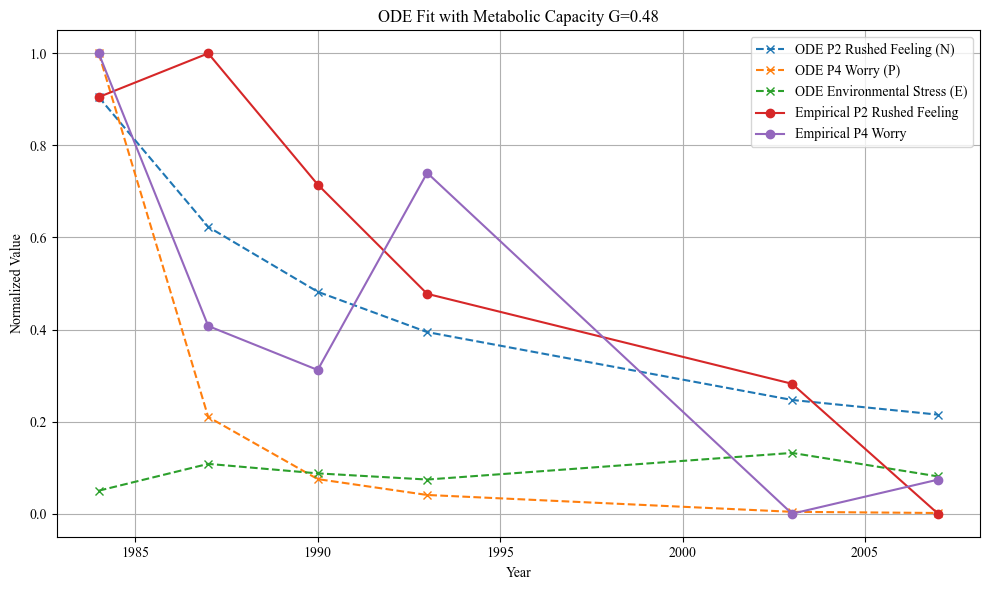

In [85]:
# MODULE A_17
#
# Associated with but not depicted in: 
#
# APPENDIX C.5: Metabolic Capacity Sensitivity Sweep
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# === Trait Entropy Data ===
data = {
    "Year": [1984, 1987, 1990, 1993, 2003, 2007],
    "P9 Satisfaction": [2.0260, 1.9559, 1.9783, 1.9952, 1.7102, 1.7284],
    "L10 Fulfillment": [2.2521, 2.1900, 2.1779, 2.1668, 2.1250, 2.1041],
    "P4 Worry": [2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279],
    "P8 Hot-Tempered": [2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556],
    "P11 Indignant": [2.2481, 2.2181, 2.2193, 2.2374, 2.2025, 2.1867],
    "L11 Depressed": [1.9549, 1.8902, 1.9110, 1.9503, 1.8526, 1.8764],
    "N49 Curiosity": [2.2429, 2.2265, 2.2022, 2.2113, 2.1799, 2.1501],
    "S28 Excitement Preference": [2.2402, 2.1675, 2.1284, 2.1266, 2.0950, 2.0190],
    "I8 Impulsivity": [2.1984, 2.1799, 2.1970, 2.2063, 2.1483, 2.1020],
    "A1 Competitive Ambition": [1.9748, 1.8601, 1.9016, 1.9649, 1.9649, 1.9936],
    "L1 Life Optimism": [2.1659, 2.0975, 2.0527, 2.0287, 1.9884, 1.9931],
    "P2 Rushed Feeling": [2.2690, 2.2760, 2.2550, 2.2375, 2.2231, 2.2023],
}

df = pd.DataFrame(data)
trait_x = "P2 Rushed Feeling"
trait_y = "P4 Worry"

years = np.array(df["Year"])
t_data = years - years[0]

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

N_empirical = normalize(df[trait_x].values)
P_empirical = normalize(df[trait_y].values)

# === Updated ODE System with metabolic capacity G ===
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K, G):
    N, P, E = y
    omega = 0.8
    amplitude = 0.05
    E_dynamic = c1 * P + c2 * N + c3 * E
    dNdt = mu * N - alpha * N**2 - beta**2 * N * P
    dPdt = mu * P - beta * P * (E_dynamic / G)
    dEdt = gamma * E * (N / (N + K)) + amplitude * 0.5 * np.sin(omega * t)
    return [dNdt, dPdt, dEdt]

# === Parameters ===
mu    = 0.00001
alpha = 0.15
beta  = 0.16746
gamma = 0.03
c1    = 2.0
c2    = 0.21
c3    = 5.60
K     = 0.5
G     = 0.480  # Can be varied for testing metabolic constraint

# === Initial Conditions and Simulation ===
init_conditions = [N_empirical[0], P_empirical[0], 0.05]
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K, G))
N_model, P_model, E_model = sol.T

# === Metrics ===
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)
rN, pN = pearsonr(N_empirical, N_model)
rP, pP = pearsonr(P_empirical, P_model)

# === DTW Function ===
def dtw_distance(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

dtwN = dtw_distance(N_empirical, N_model)
dtwP = dtw_distance(P_empirical, P_model)

# === Output ===
print(f"Parameters: mu={mu}, alpha={alpha}, beta={beta}, gamma={gamma}, c1={c1}, c2={c2}, c3={c3}, K={K}, G={G}")
print(f"RMSE: {trait_x}={rmse_N:.4f}, {trait_y}={rmse_P:.4f}")
print(f"R²: {trait_x}={r2_N:.4f}, {trait_y}={r2_P:.4f}")
print(f"Pearson r: {trait_x}={rN:.3f} (p={pN:.3f}), {trait_y}={rP:.3f} (p={pP:.3f})")
print(f"DTW distance: {trait_x}={dtwN:.3f}, {trait_y}={dtwP:.3f}")

# === Plot ===
plt.figure(figsize=(10, 6))
plt.plot(years, N_model, 'x--', label=f'ODE {trait_x} (N)')
plt.plot(years, P_model, 'x--', label=f'ODE {trait_y} (P)')
plt.plot(years, E_model, 'x--', label='ODE Environmental Stress (E)')
plt.plot(years, N_empirical, 'o-', label=f'Empirical {trait_x}')
plt.plot(years, P_empirical, 'o-', label=f'Empirical {trait_y}')
plt.title(f"ODE Fit with Metabolic Capacity G={G}")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Parameters: mu=1e-05, alpha=0.15 beta=0.16746, gamma=0.03, c1=2.0, c2=0.21, c3=5.6, K=0.5, G=0.95
RMSE: P2 Rushed Feeling=0.2085, P4 Worry=0.2556
R²: P2 Rushed Feeling=0.6449, P4 Worry=0.4753
Pearson r: P2 Rushed Feeling=0.865 (p=0.026), P4 Worry=0.797 (p=0.058)
DTW distance: P2 Rushed Feeling=0.543, P4 Worry=0.797


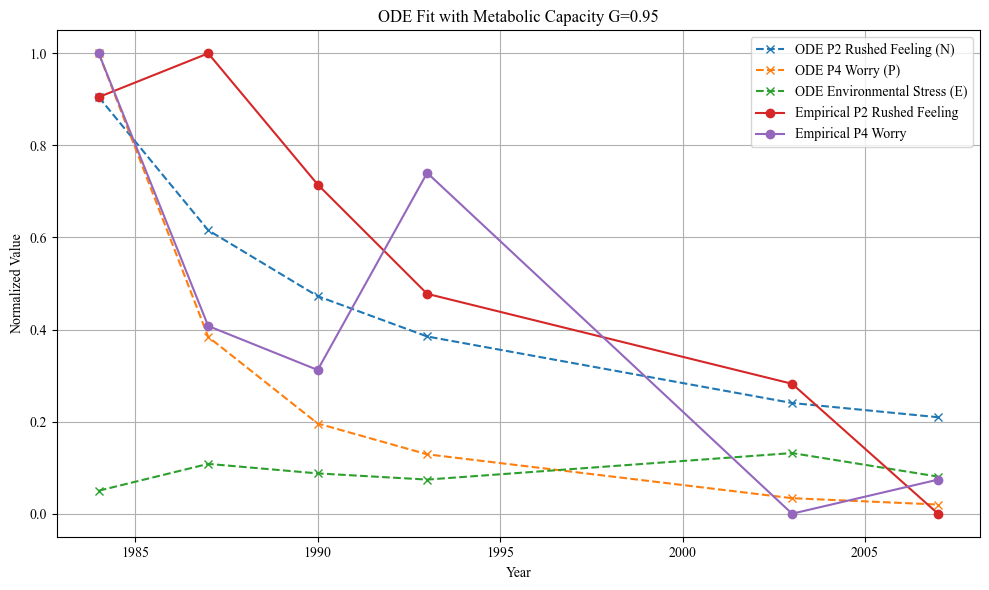

In [87]:
# MODULE A_18
#
# Associated with but not depicted in: 
#
# APPENDIX C.5: Metabolic Capacity Sensitivity Sweep
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# === Trait Entropy Data ===
data = {
    "Year": [1984, 1987, 1990, 1993, 2003, 2007],
    "P9 Satisfaction": [2.0260, 1.9559, 1.9783, 1.9952, 1.7102, 1.7284],
    "L10 Fulfillment": [2.2521, 2.1900, 2.1779, 2.1668, 2.1250, 2.1041],
    "P4 Worry": [2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279],
    "P8 Hot-Tempered": [2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556],
    "P11 Indignant": [2.2481, 2.2181, 2.2193, 2.2374, 2.2025, 2.1867],
    "L11 Depressed": [1.9549, 1.8902, 1.9110, 1.9503, 1.8526, 1.8764],
    "N49 Curiosity": [2.2429, 2.2265, 2.2022, 2.2113, 2.1799, 2.1501],
    "S28 Excitement Preference": [2.2402, 2.1675, 2.1284, 2.1266, 2.0950, 2.0190],
    "I8 Impulsivity": [2.1984, 2.1799, 2.1970, 2.2063, 2.1483, 2.1020],
    "A1 Competitive Ambition": [1.9748, 1.8601, 1.9016, 1.9649, 1.9649, 1.9936],
    "L1 Life Optimism": [2.1659, 2.0975, 2.0527, 2.0287, 1.9884, 1.9931],
    "P2 Rushed Feeling": [2.2690, 2.2760, 2.2550, 2.2375, 2.2231, 2.2023],
}

df = pd.DataFrame(data)
trait_x = "P2 Rushed Feeling"
trait_y = "P4 Worry"

years = np.array(df["Year"])
t_data = years - years[0]

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

N_empirical = normalize(df[trait_x].values)
P_empirical = normalize(df[trait_y].values)

# === Updated ODE System with metabolic capacity G ===
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K, G):
    N, P, E = y
    omega = 0.8
    amplitude = 0.05
    E_dynamic = c1 * P + c2 * N + c3 * E
    dNdt = mu * N - alpha * N**2 - beta**2 * N * P
    dPdt = mu * P - beta * P * (E_dynamic / G)
    dEdt = gamma * E * (N / (N + K)) + amplitude * 0.5 * np.sin(omega * t)
    return [dNdt, dPdt, dEdt]

# === Parameters ===
mu    = 0.00001
alpha = 0.15
beta  = 0.16746
gamma = 0.03
c1    = 2.0
c2    = 0.21
c3    = 5.60
K     = 0.5
G     = 0.950  # Can be varied for testing metabolic constraint

# === Initial Conditions and Simulation ===
init_conditions = [N_empirical[0], P_empirical[0], 0.05]
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K, G))
N_model, P_model, E_model = sol.T

# === Metrics ===
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)
rN, pN = pearsonr(N_empirical, N_model)
rP, pP = pearsonr(P_empirical, P_model)

# === DTW Function ===
def dtw_distance(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

dtwN = dtw_distance(N_empirical, N_model)
dtwP = dtw_distance(P_empirical, P_model)

# === Output ===
print(f"Parameters: mu={mu}, alpha={alpha} beta={beta}, gamma={gamma}, c1={c1}, c2={c2}, c3={c3}, K={K}, G={G}")
print(f"RMSE: {trait_x}={rmse_N:.4f}, {trait_y}={rmse_P:.4f}")
print(f"R²: {trait_x}={r2_N:.4f}, {trait_y}={r2_P:.4f}")
print(f"Pearson r: {trait_x}={rN:.3f} (p={pN:.3f}), {trait_y}={rP:.3f} (p={pP:.3f})")
print(f"DTW distance: {trait_x}={dtwN:.3f}, {trait_y}={dtwP:.3f}")

# === Plot ===
plt.figure(figsize=(10, 6))
plt.plot(years, N_model, 'x--', label=f'ODE {trait_x} (N)')
plt.plot(years, P_model, 'x--', label=f'ODE {trait_y} (P)')
plt.plot(years, E_model, 'x--', label='ODE Environmental Stress (E)')
plt.plot(years, N_empirical, 'o-', label=f'Empirical {trait_x}')
plt.plot(years, P_empirical, 'o-', label=f'Empirical {trait_y}')
plt.title(f"ODE Fit with Metabolic Capacity G={G}")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Parameters: mu=1e-05, alpha =0.15, beta=0.16746, gamma=0.03, c1=2.0, c2=0.21, c3=5.6, K=0.5, G=1.48
RMSE: P2 Rushed Feeling=0.2109, P4 Worry=0.2197
R²: P2 Rushed Feeling=0.6364, P4 Worry=0.6121
Pearson r: P2 Rushed Feeling=0.863 (p=0.027), P4 Worry=0.809 (p=0.051)
DTW distance: P2 Rushed Feeling=0.558, P4 Worry=0.729


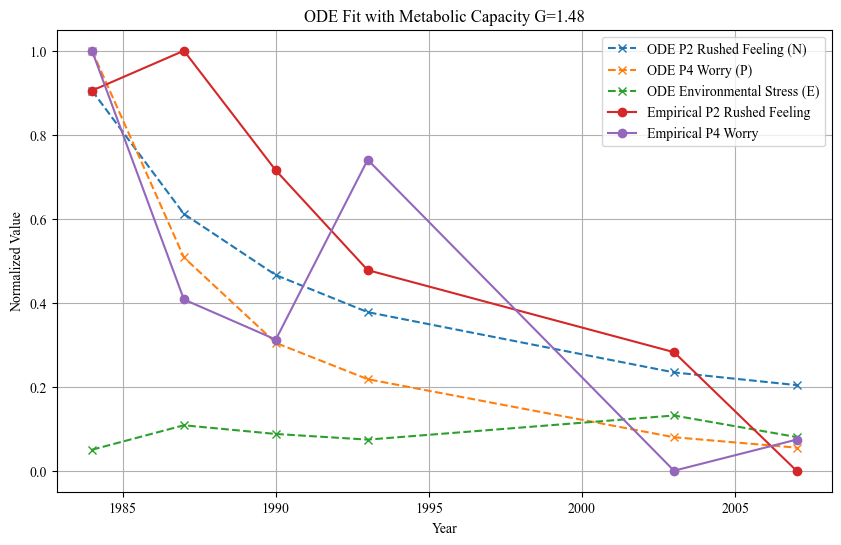

In [89]:
# MODULE A_19
# To Generate Supplemental Figure 8
# From APPENDIX C.5: Metabolic Capacity Sensitivity Sweep
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

# === Trait Entropy Data ===
data = {
    "Year": [1984, 1987, 1990, 1993, 2003, 2007],
    "P9 Satisfaction": [2.0260, 1.9559, 1.9783, 1.9952, 1.7102, 1.7284],
    "L10 Fulfillment": [2.2521, 2.1900, 2.1779, 2.1668, 2.1250, 2.1041],
    "P4 Worry": [2.2142, 2.1590, 2.1501, 2.1900, 2.1210, 2.1279],
    "P8 Hot-Tempered": [2.0755, 2.0014, 2.0219, 1.9978, 1.8980, 1.9556],
    "P11 Indignant": [2.2481, 2.2181, 2.2193, 2.2374, 2.2025, 2.1867],
    "L11 Depressed": [1.9549, 1.8902, 1.9110, 1.9503, 1.8526, 1.8764],
    "N49 Curiosity": [2.2429, 2.2265, 2.2022, 2.2113, 2.1799, 2.1501],
    "S28 Excitement Preference": [2.2402, 2.1675, 2.1284, 2.1266, 2.0950, 2.0190],
    "I8 Impulsivity": [2.1984, 2.1799, 2.1970, 2.2063, 2.1483, 2.1020],
    "A1 Competitive Ambition": [1.9748, 1.8601, 1.9016, 1.9649, 1.9649, 1.9936],
    "L1 Life Optimism": [2.1659, 2.0975, 2.0527, 2.0287, 1.9884, 1.9931],
    "P2 Rushed Feeling": [2.2690, 2.2760, 2.2550, 2.2375, 2.2231, 2.2023],
}

df = pd.DataFrame(data)
trait_x = "P2 Rushed Feeling"
trait_y = "P4 Worry"

years = np.array(df["Year"])
t_data = years - years[0]

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

N_empirical = normalize(df[trait_x].values)
P_empirical = normalize(df[trait_y].values)

# === Updated ODE System with metabolic capacity G ===
def system(y, t, mu, alpha, beta, gamma, c1, c2, c3, K, G):
    N, P, E = y
    omega = 0.8
    amplitude = 0.05
    E_dynamic = c1 * P + c2 * N + c3 * E
    dNdt = mu * N - alpha * N**2 - beta**2 * N * P
    dPdt = mu * P - beta * P * (E_dynamic / G)
    dEdt = gamma * E * (N / (N + K)) + amplitude * 0.5 * np.sin(omega * t)
    return [dNdt, dPdt, dEdt]

# === Parameters ===
mu    = 0.00001
alpha = 0.15
beta  = 0.16746
gamma = 0.03
c1    = 2.0
c2    = 0.21
c3    = 5.60
K     = 0.5
G     = 1.480  # Can be varied for testing metabolic constraint

# === Initial Conditions and Simulation ===
init_conditions = [N_empirical[0], P_empirical[0], 0.05]
sol = odeint(system, init_conditions, t_data, args=(mu, alpha, beta, gamma, c1, c2, c3, K, G))
N_model, P_model, E_model = sol.T

# === Metrics ===
rmse_N = np.sqrt(mean_squared_error(N_empirical, N_model))
rmse_P = np.sqrt(mean_squared_error(P_empirical, P_model))
r2_N = r2_score(N_empirical, N_model)
r2_P = r2_score(P_empirical, P_model)
rN, pN = pearsonr(N_empirical, N_model)
rP, pP = pearsonr(P_empirical, P_model)

# === DTW Function ===
def dtw_distance(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

dtwN = dtw_distance(N_empirical, N_model)
dtwP = dtw_distance(P_empirical, P_model)

# === Output ===
print(f"Parameters: mu={mu}, alpha ={alpha}, beta={beta}, gamma={gamma}, c1={c1}, c2={c2}, c3={c3}, K={K}, G={G}")
print(f"RMSE: {trait_x}={rmse_N:.4f}, {trait_y}={rmse_P:.4f}")
print(f"R²: {trait_x}={r2_N:.4f}, {trait_y}={r2_P:.4f}")
print(f"Pearson r: {trait_x}={rN:.3f} (p={pN:.3f}), {trait_y}={rP:.3f} (p={pP:.3f})")
print(f"DTW distance: {trait_x}={dtwN:.3f}, {trait_y}={dtwP:.3f}")

# === Plot ===
plt.figure(figsize=(10, 6))
plt.plot(years, N_model, 'x--', label=f'ODE {trait_x} (N)')
plt.plot(years, P_model, 'x--', label=f'ODE {trait_y} (P)')
plt.plot(years, E_model, 'x--', label='ODE Environmental Stress (E)')
plt.plot(years, N_empirical, 'o-', label=f'Empirical {trait_x}')
plt.plot(years, P_empirical, 'o-', label=f'Empirical {trait_y}')
plt.title(f"ODE Fit with Metabolic Capacity G={G}")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.show()
